# Paradigm 1: Portfolio Construction via Informed Selection + Optimization

## Objective

We compare **three models** for S&P 500 index replication through a two-stage approach:

**Stage 1: Informed Selection** - Select K=50 assets using different methods
- **Model 1**: Stratified Sampling (structured approach)
- **Model 2**: Clustering (data-driven approach)
- **Model 3**: Correlation Ranking (naive baseline)

**Stage 2: Weight Optimization** - Optimize weights to minimize tracking error

$$\min_w \|I - R_S w\|_2^2$$

Subject to:
- $\sum w_i = 1$ (fully invested)
- $l_i \leq w_i \leq u_i$ (weight bounds)

## Test Setup
- **Universe**: ~500 S&P 500 constituents from sp500_tickers.csv
- **Period**: 2020-2023  
- **Selected Assets**: K=50 from N constituents
- **Index Returns**: Market-cap weighted returns of all constituents
- **Benchmark**: Buy-and-hold market-cap weighted portfolio

In [5]:
# Import required libraries
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from pathlib import Path
import warnings
import importlib
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# Import custom modules from project
import sys
# Add parent directory to path to access shared modules (data.py, config.py)
sys.path.insert(0, str(Path().absolute().parent))

# Import and reload modules to get latest changes
import data
import config
import models
import optimization
import backtest
import backtest_wang

# Reload modules to get any recent changes
importlib.reload(data)
importlib.reload(config)
importlib.reload(models)
importlib.reload(optimization)
importlib.reload(backtest)
importlib.reload(backtest_wang)

from data import DataHandler
from models import StratifiedSamplingModel, ClusteringModel, CorrelationRankingModel
from optimization import PortfolioOptimizer
from backtest import BacktestEngine, StrategyComparator
from backtest_wang import WangBacktestEngine, WangComparator
from config import DATA_PARAMS, PORTFOLIO_PARAMS, OPTIMIZATION_PARAMS

print("✓ All libraries and custom modules imported successfully")

✓ All libraries and custom modules imported successfully


## Section 1: Data Fetching and Preparation

Fetch S&P 500 index and constituent data, compute returns and correlations.

In [6]:
# Initialize data handler
data_handler = DataHandler(
    index_ticker="^GSPC",
    start_date=DATA_PARAMS["start_date"],
    end_date=DATA_PARAMS["end_date"],
    data_dir="../data"  # Access shared data folder at root level
)

# Try to load cached data first
print("Checking for cached data...")
print("=" * 60)

if data_handler.load_data(prefix="sp500"):
    print("Using cached S&P 500 data")
else:
    print("No cached data found. Fetching fresh data...")
    print("=" * 60)
    
    # Fetch index data
    index_data = data_handler.fetch_index_data()
    print(f"✓ Index data fetched: {len(index_data)} trading days")
    
    # Fetch S&P 500 constituents (from CSV file)
    constituents = data_handler.fetch_sp500_constituents()
    print(f"✓ Found {len(constituents)} S&P 500 constituents")
    
    # Fetch constituent data (keeps FULL universe for benchmark + filtered for strategies)
    constituents_data = data_handler.fetch_constituents_data(constituents)
    
    if constituents_data is not None:
        print(f"✓ Data processing complete:")
        print(f"  - Full universe: {len(data_handler.constituents_data_full.columns)} stocks (for benchmark)")
        print(f"  - Filtered universe: {len(constituents_data.columns)} stocks (for strategies)")
    else:
        print("✗ Error: Could not fetch constituent data")
        raise ValueError("Failed to fetch constituent data")
    
    # Compute returns (using market-cap weighted index from FULL universe)
    returns, index_returns = data_handler.compute_returns(use_market_cap_weights=True)
    print(f"✓ Computed returns for {len(returns.columns)} filtered assets (strategies)")
    print(f"✓ Index returns: Market-cap weighted from full universe (~500 stocks)")
    
    # Compute correlations
    correlation_matrix = data_handler.compute_correlation_matrix()
    print(f"✓ Computed correlations with index")
    
    # Save data to files
    print("\nSaving data to cache...")
    data_handler.save_data(prefix="sp500")

print("\n" + "=" * 60)
print(f"Data Summary:")
print(f"  Date Range: {data_handler.returns.index[0].date()} to {data_handler.returns.index[-1].date()}")
print(f"  Benchmark Universe: ~500 S&P 500 stocks (market-cap weighted)")
print(f"  Strategy Universe: {len(data_handler.returns.columns)} stocks (complete data)")
print(f"  Number of Trading Days: {len(data_handler.returns)}")
print(f"  Top 5 Correlated Assets:")
print(data_handler.correlation_matrix.head(5))

# Convenience variables for ease of use
returns = data_handler.returns
index_returns = data_handler.index_returns
correlation_matrix = data_handler.correlation_matrix

# Compute sector statistics
sector_mapping = data_handler.get_sector_mapping()
if sector_mapping and hasattr(data_handler, 'sector_data') and data_handler.sector_data is not None:
    sector_stats_data = []
    for sector in sector_mapping.values():
        sector_tickers = [ticker for ticker, s in sector_mapping.items() if s == sector and ticker in returns.columns]
        if sector_tickers:
            sector_corrs = correlation_matrix[correlation_matrix.index.isin(sector_tickers)]
            sector_stats_data.append({
                'Sector': sector,
                'Count': len(sector_tickers),
                'Pct_of_Universe': len(sector_tickers) / len(returns.columns) * 100,
                'Mean_Correlation': sector_corrs.mean(),
                'Min_Correlation': sector_corrs.min(),
                'Max_Correlation': sector_corrs.max()
            })
    sector_stats = pd.DataFrame(sector_stats_data).sort_values('Count', ascending=False)
else:
    # Fallback: create empty DataFrame with correct structure
    sector_stats = pd.DataFrame(columns=['Sector', 'Count', 'Pct_of_Universe', 'Mean_Correlation', 'Min_Correlation', 'Max_Correlation'])
    print("⚠ Sector data not available - sector statistics will be empty")

Checking for cached data...
✗ Error loading data: read_csv() got an unexpected keyword argument 'squeeze'
No cached data found. Fetching fresh data...
Fetching ^GSPC data...
✓ Index data fetched: 502 trading days
Fetching S&P 500 constituents...
✓ Successfully loaded 503 tickers from ..\data\sp500_tickers.csv
✓ Found 503 S&P 500 constituents
Fetching data for 503 constituents...


$BF.B: possibly delisted; no price data found  (1d 2024-01-01 -> 2026-01-01)
$BRK.B: possibly delisted; no timezone found

2 Failed downloads:
['BF.B']: possibly delisted; no price data found  (1d 2024-01-01 -> 2026-01-01)
['BRK.B']: possibly delisted; no timezone found


$FI: possibly delisted; no timezone found

1 Failed download:
['FI']: possibly delisted; no timezone found


$K: possibly delisted; no timezone found
$IPG: possibly delisted; no timezone found

2 Failed downloads:
['K', 'IPG']: possibly delisted; no timezone found


$WBA: possibly delisted; no timezone found

1 Failed download:
['WBA']: possibly delisted; no timezone found


...

  Batch 4/7...


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: IPG"}}}
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: K"}}}


  Batch 5/7...
  Batch 6/7...
  Batch 7/7...


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: WBA"}}}


✓ Successfully fetched market caps for 303 tickers
Computing time-varying market-cap weighted returns...
✓ Computed market-cap weighted returns from full universe
   Average stocks per day: 302/309
   Largest weights: {'NVDA': 0.09462085449645044, 'AAPL': 0.0843270991894632, 'GOOGL': 0.07815941437703526, 'GOOG': 0.07810092904076046, 'MSFT': 0.06275946602936626}
✓ Computed returns for 303 filtered assets (strategies)
✓ Index returns: Market-cap weighted from full universe (~500 stocks)
✓ Computed correlations with index

Saving data to cache...
✓ Saved full universe prices to ..\data\sp500_prices_full.csv
✓ Saved filtered constituent prices to ..\data\sp500_prices.csv
✓ Saved index prices to ..\data\sp500_index.csv
✓ Saved filtered constituent returns to ..\data\sp500_returns.csv
✓ Saved market-cap weighted index returns to ..\data\sp500_index_returns.csv
✓ Saved correlations to ..\data\sp500_correlations.csv
✓ Saved constituents list to ..\data\sp500_constituents.txt

Data Summary:
  D

## Section 1.5: Data Export and Verification

Export comprehensive S&P 500 data for analysis and verification.

In [8]:
# COMPREHENSIVE DATA EXPORT AND VERIFICATION
from pathlib import Path

print("=" * 80)
print("COMPREHENSIVE S&P 500 DATA EXPORT AND VERIFICATION")
print("=" * 80)

# Create exports directory for reference data
export_dir_data = Path("../data/exports")
export_dir_data.mkdir(exist_ok=True, parents=True)

# Create results directory for Paradigm 1 results
export_dir = Path("./results")
export_dir.mkdir(exist_ok=True, parents=True)

# EXPORT 1: Constituent Information
print("\n1. Exporting constituent information...")
constituents_info = pd.DataFrame({
    'Ticker': data_handler.constituents_list,
    'In_Dataset': [ticker in returns.columns for ticker in data_handler.constituents_list]
})
constituents_info.to_csv(export_dir_data / 'sp500_constituents_info.csv', index=False)
print(f"   ✓ Saved {len(constituents_info)} constituents")
print(f"   With complete data: {constituents_info['In_Dataset'].sum()}")

# EXPORT 2: Correlations with Sectors
print("\n2. Exporting correlations with sector mapping...")
if hasattr(data_handler, 'sector_data') and data_handler.sector_data is not None:
    try:
        # Ensure correlation_matrix is a Series with ticker index
        if not isinstance(correlation_matrix.index, pd.Index):
            correlation_matrix.index = returns.columns
        
        # Create mapping from ticker to sector
        sector_mapping = data_handler.sector_data.set_index('Symbol')['GICS Sector'].to_dict()
        
        # Create correlation DataFrame with sectors
        corr_with_sectors = pd.DataFrame({
            'Ticker': correlation_matrix.index,
            'Correlation': correlation_matrix.values,
            'Sector': [sector_mapping.get(ticker, 'Unknown') for ticker in correlation_matrix.index]
        })
        
        corr_with_sectors.to_csv(export_dir_data / 'sp500_correlations_with_sectors.csv', index=False)
        print(f"   ✓ Saved correlations for {len(corr_with_sectors)} assets with sector information")
    except Exception as e:
        print(f"   ⚠ Could not export with sectors: {e}")
else:
    print("   ⚠ Sector data not available")

# EXPORT 3: Sector Statistics
print("\n3. Exporting sector statistics...")
sector_stats.to_csv(export_dir_data / 'sp500_sector_statistics.csv')
print(f"   ✓ Saved statistics for {len(sector_stats)} sectors")

print("\n" + "=" * 80)
print("DATA VERIFICATION SUMMARY")
print("=" * 80)
print(f"📊 Dataset: {len(returns.columns)} assets with complete data")
print(f"📅 Period: {returns.index[0].date()} to {returns.index[-1].date()} ({len(returns)} days)")
print(f"🏢 Sectors: {len(sector_stats)} unique sectors")
print(f"🔗 Correlation: [{correlation_matrix.min():.4f}, {correlation_matrix.max():.4f}]")
print(f"\n💾 Reference data saved to: {export_dir_data.absolute()}")
print(f"💾 Results will be saved to: {export_dir.absolute()}")
print("=" * 80)

COMPREHENSIVE S&P 500 DATA EXPORT AND VERIFICATION

1. Exporting constituent information...
   ✓ Saved 503 constituents
   With complete data: 303

2. Exporting correlations with sector mapping...
   ✓ Saved correlations for 303 assets with sector information

3. Exporting sector statistics...
   ✓ Saved statistics for 503 sectors

DATA VERIFICATION SUMMARY
📊 Dataset: 303 assets with complete data
📅 Period: 2024-03-28 to 2025-12-31 (442 days)
🏢 Sectors: 503 unique sectors
🔗 Correlation: [-0.2346, 0.7543]

💾 Reference data saved to: c:\Users\aicha\Downloads\these master\Structured-vs-Endogenous-Portfolio-Construction-for-Partial-Index-Replication\paradigm1\..\data\exports
💾 Results will be saved to: c:\Users\aicha\Downloads\these master\Structured-vs-Endogenous-Portfolio-Construction-for-Partial-Index-Replication\paradigm1\results


## Section 2: Asset Selection Using Three Models

Compare three different methods to select K=50 assets from the available constituents.

In [9]:
# Model 1: Stratified Sampling
print("\n" + "=" * 60)
print("MODEL 1: STRATIFIED SAMPLING (Baseline)")
print("=" * 60)

model1_stratified = StratifiedSamplingModel(K=PORTFOLIO_PARAMS["K"], num_strata=PORTFOLIO_PARAMS["num_strata"])
sector_mapping = data_handler.get_sector_mapping()

selected_assets_1 = model1_stratified.select(
    returns=returns,
    correlation_matrix=correlation_matrix,
    sector_mapping=sector_mapping
)

print(f"✓ Selected {len(selected_assets_1)} assets using stratified sampling")
print(f"\nSelected assets:\n{selected_assets_1}")
print(f"\nCorrelations of selected assets:")
print(correlation_matrix[correlation_matrix.index.isin(selected_assets_1)].head(10))


MODEL 1: STRATIFIED SAMPLING (Baseline)
Stratified Sampling: Selecting from 11 sectors
  Industrials: 8/8 assets
  Health Care: 7/7 assets
  Information Technology: 9/9 assets
  Utilities: 3/3 assets
  Financials: 7/7 assets
  Materials: 2/2 assets
  Consumer Discretionary: 5/5 assets
  Real Estate: 2/2 assets
  Communication Services: 2/2 assets
  Consumer Staples: 4/4 assets
  Energy: 1/1 assets
Total selected: 50 assets
✓ Selected 50 assets using stratified sampling

Selected assets:
['PH', 'HUBB', 'FTV', 'CMI', 'IR', 'PWR', 'PNR', 'GE', 'GEHC', 'A', 'MTD', 'SYK', 'RVTY', 'DHR', 'IDXX', 'NVDA', 'MSFT', 'APH', 'ADI', 'MPWR', 'QCOM', 'AAPL', 'AMAT', 'NXPI', 'NRG', 'CEG', 'PEG', 'TROW', 'GS', 'MS', 'APO', 'AXP', 'C', 'AMP', 'FCX', 'STLD', 'AMZN', 'TSLA', 'RL', 'HLT', 'RCL', 'HST', 'SPG', 'GOOG', 'GOOGL', 'COST', 'TGT', 'STZ', 'DLTR', 'SLB']

Correlations of selected assets:
Ticker
AMZN     0.754282
NVDA     0.744742
MSFT     0.728558
GOOG     0.727767
GOOGL    0.722918
APH      0.7200

In [10]:
# Model 2: Clustering
print("\n" + "=" * 60)
print("MODEL 2: CLUSTERING (Data-Driven)")
print("=" * 60)

model2_clustering = ClusteringModel(K=PORTFOLIO_PARAMS["K"], num_clusters=PORTFOLIO_PARAMS["num_clusters"])
selected_assets_2 = model2_clustering.select(
    returns=returns,
    correlation_matrix=correlation_matrix
)

print(f"✓ Selected {len(selected_assets_2)} assets using clustering method")
print(f"\nSelected assets:\n{selected_assets_2}")
print(f"\nCorrelations of selected assets:")
print(correlation_matrix[correlation_matrix.index.isin(selected_assets_2)].head(10))


MODEL 2: CLUSTERING (Data-Driven)
Clustering: Performing K-means with 10 clusters on return features
  Cluster 0: 39 assets → selected 6
  Cluster 1: 69 assets → selected 11
  Cluster 2: 1 assets → selected 1
  Cluster 3: 12 assets → selected 1
  Cluster 4: 42 assets → selected 6
  Cluster 5: 46 assets → selected 7
  Cluster 6: 20 assets → selected 3
  Cluster 7: 1 assets → selected 1
  Cluster 8: 71 assets → selected 11
  Cluster 9: 2 assets → selected 1
  Added 2 additional assets to reach K=50
Total selected: 50 assets
✓ Selected 50 assets using clustering method

Selected assets:
['AIZ', 'PEG', 'AIG', 'CINF', 'SRE', 'HIG', 'MSFT', 'MCO', 'HLT', 'PANW', 'CSCO', 'GE', 'TT', 'NDAQ', 'ADSK', 'NOW', 'NWSA', 'SMCI', 'SLB', 'FTV', 'PNR', 'GEHC', 'NDSN', 'TXT', 'A', 'REG', 'DOC', 'STE', 'ZTS', 'OTIS', 'AMCR', 'REGN', 'NVDA', 'APH', 'MPWR', 'TTD', 'AMZN', 'GOOG', 'GOOGL', 'ADI', 'QCOM', 'TROW', 'GS', 'AAPL', 'PH', 'MS', 'NXPI', 'DLTR', 'AMAT', 'TEL']

Correlations of selected assets:
Ticke

In [12]:
# Model 3: Correlation Ranking
print("\n" + "=" * 60)
print("MODEL 3: CORRELATION RANKING (Naive Baseline)")
print("=" * 60)

model3_correlation = CorrelationRankingModel(K=PORTFOLIO_PARAMS["K"])
selected_assets_3 = model3_correlation.select(
    returns=returns,
    correlation_matrix=correlation_matrix
)

print(f"✓ Selected {len(selected_assets_3)} assets using correlation ranking")
print(f"\nSelected assets:\n{selected_assets_3}")
print(f"\nCorrelations of selected assets:")
print(correlation_matrix[correlation_matrix.index.isin(selected_assets_3)].head(10))

# Summary of selections
print("\n" + "=" * 60)
print("SELECTION SUMMARY")
print("=" * 60)
print(f"Model 1 (Stratified):  {len(selected_assets_1)} assets, avg correlation: {correlation_matrix[correlation_matrix.index.isin(selected_assets_1)].mean():.4f}")
print(f"Model 2 (Clustering):  {len(selected_assets_2)} assets, avg correlation: {correlation_matrix[correlation_matrix.index.isin(selected_assets_2)].mean():.4f}")
print(f"Model 3 (Correlation): {len(selected_assets_3)} assets, avg correlation: {correlation_matrix[correlation_matrix.index.isin(selected_assets_3)].mean():.4f}")
print(f"\nOverlap between models:")
overlap_12 = len(set(selected_assets_1) & set(selected_assets_2))
overlap_13 = len(set(selected_assets_1) & set(selected_assets_3))
overlap_23 = len(set(selected_assets_2) & set(selected_assets_3))
print(f"  Model 1 ∩ Model 2: {overlap_12} assets")
print(f"  Model 1 ∩ Model 3: {overlap_13} assets")
print(f"  Model 2 ∩ Model 3: {overlap_23} assets")


MODEL 3: CORRELATION RANKING (Naive Baseline)
Correlation Ranking: Selecting top 50 assets by correlation with index
  Selected asset correlations: min=0.5915, max=0.7543, mean=0.6528
✓ Selected 50 assets using correlation ranking

Selected assets:
['AMZN', 'NVDA', 'MSFT', 'GOOG', 'GOOGL', 'APH', 'ADI', 'MPWR', 'QCOM', 'TROW', 'GS', 'AAPL', 'AMAT', 'PH', 'MS', 'NXPI', 'TEL', 'APO', 'META', 'AXP', 'MU', 'AMD', 'MCHP', 'TSLA', 'C', 'HUBB', 'ZBRA', 'TER', 'NTAP', 'AMP', 'FTV', 'ANET', 'SYF', 'CMI', 'HPE', 'ON', 'IR', 'PWR', 'DELL', 'RL', 'TXN', 'MCO', 'HLT', 'RCL', 'CRWD', 'PANW', 'PNR', 'CSCO', 'GE', 'STT']

Correlations of selected assets:
Ticker
AMZN     0.754282
NVDA     0.744742
MSFT     0.728558
GOOG     0.727767
GOOGL    0.722918
APH      0.720052
ADI      0.715017
MPWR     0.707706
QCOM     0.705300
TROW     0.698740
dtype: float64

SELECTION SUMMARY
Model 1 (Stratified):  50 assets, avg correlation: 0.5886
Model 2 (Clustering):  50 assets, avg correlation: 0.5368
Model 3 (Correl

## Section 3: Weight Optimization

Optimize portfolio weights for each model to minimize tracking error: $\min_w \|I - R_S w\|_2^2$

In [13]:
# Optimize weights for all three models
print("\n" + "=" * 60)
print("WEIGHT OPTIMIZATION")
print("=" * 60)

# Model 1: Stratified Sampling
print("\nOptimizing weights for Model 1 (Stratified Sampling)...")
optimizer1 = PortfolioOptimizer(
    lower_bound=OPTIMIZATION_PARAMS["lower_bound"],
    upper_bound=OPTIMIZATION_PARAMS["upper_bound"]
)
selected_returns_1 = returns[selected_assets_1]
weights_1 = optimizer1.optimize(selected_returns_1, index_returns)
print("✓ Optimization complete")
print(f"  Objective function value: {optimizer1.optimization_result.fun:.6f}")
print(f"  Max weight: {weights_1.max():.4f}")
print(f"  Min weight: {weights_1.min():.4f}")
print(f"  Non-zero weights: {(weights_1 > 1e-6).sum()}/{len(weights_1)}")

# Model 2: Clustering
print("\nOptimizing weights for Model 2 (Clustering)...")
optimizer2 = PortfolioOptimizer()
selected_returns_2 = returns[selected_assets_2]
weights_2 = optimizer2.optimize(selected_returns_2, index_returns)
print("✓ Optimization complete")
print(f"  Objective function value: {optimizer2.optimization_result.fun:.6f}")
print(f"  Max weight: {weights_2.max():.4f}")
print(f"  Min weight: {weights_2.min():.4f}")
print(f"  Non-zero weights: {(weights_2 > 1e-6).sum()}/{len(weights_2)}")

# Model 3: Correlation Ranking
print("\nOptimizing weights for Model 3 (Correlation Ranking)...")
optimizer3 = PortfolioOptimizer()
selected_returns_3 = returns[selected_assets_3]
weights_3 = optimizer3.optimize(selected_returns_3, index_returns)
print("✓ Optimization complete")
print(f"  Objective function value: {optimizer3.optimization_result.fun:.6f}")
print(f"  Max weight: {weights_3.max():.4f}")
print(f"  Min weight: {weights_3.min():.4f}")
print(f"  Non-zero weights: {(weights_3 > 1e-6).sum()}/{len(weights_3)}")

print("\n" + "=" * 60)


WEIGHT OPTIMIZATION

Optimizing weights for Model 1 (Stratified Sampling)...
✓ Optimization complete
  Objective function value: 0.000837
  Max weight: 0.1000
  Min weight: 0.0000
  Non-zero weights: 43/50

Optimizing weights for Model 2 (Clustering)...
✓ Optimization complete
  Objective function value: 0.001021
  Max weight: 0.0982
  Min weight: 0.0000
  Non-zero weights: 45/50

Optimizing weights for Model 3 (Correlation Ranking)...
✓ Optimization complete
  Objective function value: 0.001408
  Max weight: 0.1000
  Min weight: 0.0000
  Non-zero weights: 27/50



## Section 4: Backtesting and Performance Analysis

Test all three strategies on the full dataset and compare performance metrics.

In [14]:
# Initialize backtesting engine
backtest_engine = BacktestEngine(
    index_prices=data_handler.index_data,
    constituents_prices=data_handler.constituents_data,
    index_returns=data_handler.index_returns,
    constituents_returns=data_handler.returns,
    slippage=0.001
)

# Run backtests
print("\n" + "=" * 60)
print("BACKTESTING RESULTS")
print("=" * 60)

print("\nModel 1: Stratified Sampling")
result1 = backtest_engine.backtest(
    selected_assets=selected_assets_1,
    weights=weights_1
)

print("\nModel 2: Clustering")
result2 = backtest_engine.backtest(
    selected_assets=selected_assets_2,
    weights=weights_2
)

print("\nModel 3: Correlation Ranking")
result3 = backtest_engine.backtest(
    selected_assets=selected_assets_3,
    weights=weights_3
)

print("\nBenchmark: Market-Cap Weighted Index (Buy-and-Hold)")
result_sp500 = backtest_engine.backtest_index()

# Collect results
comparator = StrategyComparator()
comparator.add_result("Stratified Sampling", result1)
comparator.add_result("Clustering", result2)
comparator.add_result("Correlation Ranking", result3)
comparator.add_result("Market-Cap Weighted Index", result_sp500)

print("\n" + "=" * 60)
print("PERFORMANCE COMPARISON")
print("=" * 60)
comparison_df = comparator.get_comparison_df()
print(comparison_df.to_string())

# Save results
results_summary = comparison_df.copy()
results_summary


BACKTESTING RESULTS

Model 1: Stratified Sampling

Model 2: Clustering

Model 3: Correlation Ranking

Benchmark: Market-Cap Weighted Index (Buy-and-Hold)

PERFORMANCE COMPARISON
                           Portfolio Return (%)  Index Return (%)  Excess Return (%)  Tracking Error (%)  Mean Tracking Error (%)  Sharpe Ratio  Max Drawdown (%)  Num Assets
Stratified Sampling                   40.248888         45.904716          -5.655828            0.021807                -2.103735      1.065622        -24.409035        50.0
Clustering                            41.822954         45.904716          -4.081761            0.024109                -1.533336      1.113044        -23.465646        50.0
Correlation Ranking                   49.289433         45.904716           3.384718            0.028317                 1.631299      1.202051        -24.975206        50.0
Market-Cap Weighted Index             45.904716         45.904716           0.000000            0.000000                 0.00

,Portfolio Return (%),Index Return (%),Excess Return (%),Tracking Error (%),Mean Tracking Error (%),Sharpe Ratio,Max Drawdown (%),Num Assets
Stratified Sampling,40.248888,45.904716,-5.655828,0.021807,-2.103735,1.065622,-24.409035,50.0
Clustering,41.822954,45.904716,-4.081761,0.024109,-1.533336,1.113044,-23.465646,50.0
Correlation Ranking,49.289433,45.904716,3.384718,0.028317,1.631299,1.202051,-24.975206,50.0
Market-Cap Weighted Index,45.904716,45.904716,0.000000,0.000000,0.000000,1.199547,-22.730267,303.0


## Section 4.5: Wang et al. (2018) Compliant Evaluation

**Proper academic evaluation following Wang et al. methodology:**

This section implements the **correct** evaluation framework for Paradigm 1 (Selection + Optimization):

### Key Differences from Previous Section:
1. **Train/Test Split**: Data split into 70% in-sample (training) and 30% out-of-sample (testing)
2. **Training on In-Sample Only**: Asset selection and weight optimization performed only on training data
3. **Testing on Both Periods**: Evaluate performance on both in-sample and out-of-sample
4. **Wang et al. Metrics**:
   - **TE**: Tracking Error = sqrt((1/T) * ||I - R*w||²) 
   - **Std_TE**: Robustness measure (std of squared tracking errors)
   - **Mean_Corr**: Mean correlation of selected assets with index
   - **Consistency**: |TE_in - TE_out| (measures overfitting)

### Expected Behavior (from Wang et al.):
- **S-Strategy** (Stratified): Moderate TE, good consistency, high correlation
- **Clustering**: Data-driven selection, potentially lower TE but risk of overfitting  
- **Correlation Ranking**: Simple baseline, highest correlation but may overfit

In [15]:
# WANG ET AL. (2018) COMPLIANT EVALUATION
# Import the proper evaluation framework
import importlib
import backtest_wang
importlib.reload(backtest_wang)
from backtest_wang import WangBacktestEngine, WangComparator

print("=" * 80)
print("PARADIGM 1 EVALUATION - WANG ET AL. (2018) METHODOLOGY")
print("=" * 80)
print("\n📚 Paper: 'Structured vs Endogenous Portfolio Construction'")
print("   This evaluation follows the exact methodology from the paper\n")

# Initialize Wang backtest engine
wang_engine = WangBacktestEngine(
    returns=returns,
    index_returns=index_returns,
    correlation_matrix=correlation_matrix,
    train_ratio=0.7,  # 70% training, 30% testing
    slippage=0.001
)

# Initialize comparator
wang_comparator = WangComparator()

# Get K from config
K = PORTFOLIO_PARAMS["K"]

print(f"\n🎯 Portfolio Size: K = {K}")
print(f"📊 Universe Size: N = {len(returns.columns)}")
print(f"📅 Full Period: {returns.index[0].date()} to {returns.index[-1].date()}")

PARADIGM 1 EVALUATION - WANG ET AL. (2018) METHODOLOGY

📚 Paper: 'Structured vs Endogenous Portfolio Construction'
   This evaluation follows the exact methodology from the paper

Data split:
  In-sample:     2024-03-28 to 2025-06-23 (309 days)
  Out-of-sample: 2025-06-24 to 2025-12-31 (133 days)

🎯 Portfolio Size: K = 50
📊 Universe Size: N = 303
📅 Full Period: 2024-03-28 to 2025-12-31


In [16]:
# MODEL 1: STRATIFIED SAMPLING (S-STRATEGY from Wang et al.)
from models import StratifiedSamplingModel
from optimization import PortfolioOptimizer

model1_wang = StratifiedSamplingModel(K=K, num_strata=10)
opt1_wang = PortfolioOptimizer()

result1_wang = wang_engine.backtest_strategy(
    selection_model=model1_wang,
    optimizer=opt1_wang,
    strategy_name="S-Strategy (Stratified Sampling)",
    sector_mapping=sector_mapping
)

wang_comparator.add_result(result1_wang)


BACKTESTING: S-Strategy (Stratified Sampling)

[IN-SAMPLE PHASE]
1. Selecting assets...
Stratified Sampling: Selecting from 11 sectors
  Industrials: 8/8 assets
  Health Care: 7/7 assets
  Information Technology: 9/9 assets
  Utilities: 3/3 assets
  Financials: 7/7 assets
  Materials: 2/2 assets
  Consumer Discretionary: 5/5 assets
  Real Estate: 2/2 assets
  Communication Services: 2/2 assets
  Consumer Staples: 4/4 assets
  Energy: 1/1 assets
Total selected: 50 assets
   ✓ Selected 50 assets
2. Optimizing weights...
   ✓ Weights optimized (objective: 0.000816)
3. Computing in-sample metrics...
   ✓ IN-SAMPLE: TE=0.1625%, Std_TE=0.0005, Mean_Corr=0.6333, Return=12.94%

[OUT-OF-SAMPLE PHASE]
4. Computing out-of-sample metrics...
   ✓ OUT-OF-SAMPLE: TE=0.1912%, Std_TE=0.0005, Mean_Corr=0.3920, Return=19.63%

[FULL PERIOD]
5. Computing full period metrics...
   ✓ FULL: TE=0.1717%, Std_TE=0.0005, Mean_Corr=0.5817, Return=35.11%

WANG ET AL. EVALUATION SUMMARY: S-Strategy (Stratified Samp

In [17]:
# MODEL 2: CLUSTERING
from models import ClusteringModel

model2_wang = ClusteringModel(K=K, num_clusters=min(10, K))
opt2_wang = PortfolioOptimizer()

result2_wang = wang_engine.backtest_strategy(
    selection_model=model2_wang,
    optimizer=opt2_wang,
    strategy_name="Clustering (Data-Driven)"
)

wang_comparator.add_result(result2_wang)


BACKTESTING: Clustering (Data-Driven)

[IN-SAMPLE PHASE]
1. Selecting assets...
Clustering: Performing K-means with 10 clusters on return features
  Cluster 0: 76 assets → selected 12
  Cluster 1: 21 assets → selected 3
  Cluster 2: 42 assets → selected 6
  Cluster 3: 57 assets → selected 9
  Cluster 4: 6 assets → selected 1
  Cluster 5: 1 assets → selected 1
  Cluster 6: 10 assets → selected 1
  Cluster 7: 9 assets → selected 1
  Cluster 8: 1 assets → selected 1
  Cluster 9: 80 assets → selected 13
  Added 2 additional assets to reach K=50
Total selected: 50 assets
   ✓ Selected 50 assets
2. Optimizing weights...
   ✓ Weights optimized (objective: 0.000938)
3. Computing in-sample metrics...
   ✓ IN-SAMPLE: TE=0.1742%, Std_TE=0.0005, Mean_Corr=0.5816, Return=14.82%

[OUT-OF-SAMPLE PHASE]
4. Computing out-of-sample metrics...
   ✓ OUT-OF-SAMPLE: TE=0.2392%, Std_TE=0.0009, Mean_Corr=0.3435, Return=19.20%

[FULL PERIOD]
5. Computing full period metrics...
   ✓ FULL: TE=0.1960%, Std_TE=0.

In [18]:
# MODEL 3: CORRELATION RANKING (NAIVE BASELINE)
from models import CorrelationRankingModel

model3_wang = CorrelationRankingModel(K=K)
opt3_wang = PortfolioOptimizer()

result3_wang = wang_engine.backtest_strategy(
    selection_model=model3_wang,
    optimizer=opt3_wang,
    strategy_name="Correlation Ranking (Baseline)"
)

wang_comparator.add_result(result3_wang)


BACKTESTING: Correlation Ranking (Baseline)

[IN-SAMPLE PHASE]
1. Selecting assets...
Correlation Ranking: Selecting top 50 assets by correlation with index
  Selected asset correlations: min=0.6398, max=0.8087, mean=0.6999
   ✓ Selected 50 assets
2. Optimizing weights...
   ✓ Weights optimized (objective: 0.000945)
3. Computing in-sample metrics...
   ✓ IN-SAMPLE: TE=0.1749%, Std_TE=0.0005, Mean_Corr=0.6999, Return=16.88%

[OUT-OF-SAMPLE PHASE]
4. Computing out-of-sample metrics...
   ✓ OUT-OF-SAMPLE: TE=0.2298%, Std_TE=0.0017, Mean_Corr=0.4488, Return=19.97%

[FULL PERIOD]
5. Computing full period metrics...
   ✓ FULL: TE=0.1930%, Std_TE=0.0010, Mean_Corr=0.6401, Return=40.21%

WANG ET AL. EVALUATION SUMMARY: Correlation Ranking (Baseline)

📊 ASSET SELECTION
   Number of assets: 50
   Mean correlation: 0.6999 (in-sample), 0.4488 (out-of-sample)

📈 IN-SAMPLE PERFORMANCE
   TE_in:      0.1749%
   Std_TE_in:  0.0005
   Return_in:  16.88%
   Sharpe_in:  0.6662

📉 OUT-OF-SAMPLE PERFORMAN

In [19]:
# COMPREHENSIVE COMPARISON TABLE
wang_comparator.print_comparison()

# Save to CSV for thesis
wang_comparator.save_to_csv("./results/wang_evaluation_results.csv")

# Store for visualization
wang_comparison_df = wang_comparator.get_comparison_table()
wang_comparison_df


WANG ET AL. (2018) COMPARISON TABLE - PARADIGM 1: SELECTION + OPTIMIZATION
                                   K  Mean_Corr_in  TE_in (%)  Std_TE_in  Mean_Corr_out  TE_out (%)  Std_TE_out  Consistency  Return_in (%)  Return_out (%)  Sharpe_in  Sharpe_out
Strategy                                                                                                                                                                          
S-Strategy (Stratified Sampling)  50      0.633288   0.162511   0.000502       0.391999    0.191220    0.000487     0.028709      12.942553       19.626025   0.556946    2.873191
Clustering (Data-Driven)          50      0.581642   0.174217   0.000480       0.343466    0.239180    0.000925     0.064963      14.821996       19.203867   0.622502    2.746500
Correlation Ranking (Baseline)    50      0.699936   0.174867   0.000538       0.448787    0.229796    0.001710     0.054929      16.876373       19.966207   0.666215    2.650681

📝 INTERPRETATION GUIDE (from

,K,Mean_Corr_in,TE_in (%),Std_TE_in,Mean_Corr_out,TE_out (%),Std_TE_out,Consistency,Return_in (%),Return_out (%),Sharpe_in,Sharpe_out
Strategy,,,,,,,,,,,,
S-Strategy (Stratified Sampling),50,0.633288,0.162511,0.000502,0.391999,0.191220,0.000487,0.028709,12.942553,19.626025,0.556946,2.873191
Clustering (Data-Driven),50,0.581642,0.174217,0.000480,0.343466,0.239180,0.000925,0.064963,14.821996,19.203867,0.622502,2.746500
Correlation Ranking (Baseline),50,0.699936,0.174867,0.000538,0.448787,0.229796,0.001710,0.054929,16.876373,19.966207,0.666215,2.650681


In [20]:
# VERIFICATION: Check that Mean_Corr_in ≠ Mean_Corr_out (CRITICAL FIX)
print("=" * 80)
print("VERIFICATION: Mean_Corr computed on correct periods")
print("=" * 80)
print("\nBEFORE FIX: Mean_Corr_in = Mean_Corr_out for all strategies (BUG)")
print("AFTER FIX: Mean_Corr_in ≠ Mean_Corr_out (correlations differ by period)\n")

for strategy in wang_comparison_df.index:
    corr_in = wang_comparison_df.loc[strategy, 'Mean_Corr_in']
    corr_out = wang_comparison_df.loc[strategy, 'Mean_Corr_out']
    diff = abs(corr_in - corr_out)
    
    if diff < 1e-10:
        status = "❌ ERROR: Same values (computed on full sample)"
    else:
        status = f"✓ Different (Δ = {diff:.6f})"
    
    print(f"{strategy}:")
    print(f"  Mean_Corr_in:  {corr_in:.6f}")
    print(f"  Mean_Corr_out: {corr_out:.6f}")
    print(f"  {status}\n")

print("=" * 80)
print("✓ Fix verified: Correlations now computed on correct time periods")
print("=" * 80)

VERIFICATION: Mean_Corr computed on correct periods

BEFORE FIX: Mean_Corr_in = Mean_Corr_out for all strategies (BUG)
AFTER FIX: Mean_Corr_in ≠ Mean_Corr_out (correlations differ by period)

S-Strategy (Stratified Sampling):
  Mean_Corr_in:  0.633288
  Mean_Corr_out: 0.391999
  ✓ Different (Δ = 0.241289)

Clustering (Data-Driven):
  Mean_Corr_in:  0.581642
  Mean_Corr_out: 0.343466
  ✓ Different (Δ = 0.238176)

Correlation Ranking (Baseline):
  Mean_Corr_in:  0.699936
  Mean_Corr_out: 0.448787
  ✓ Different (Δ = 0.251149)

✓ Fix verified: Correlations now computed on correct time periods


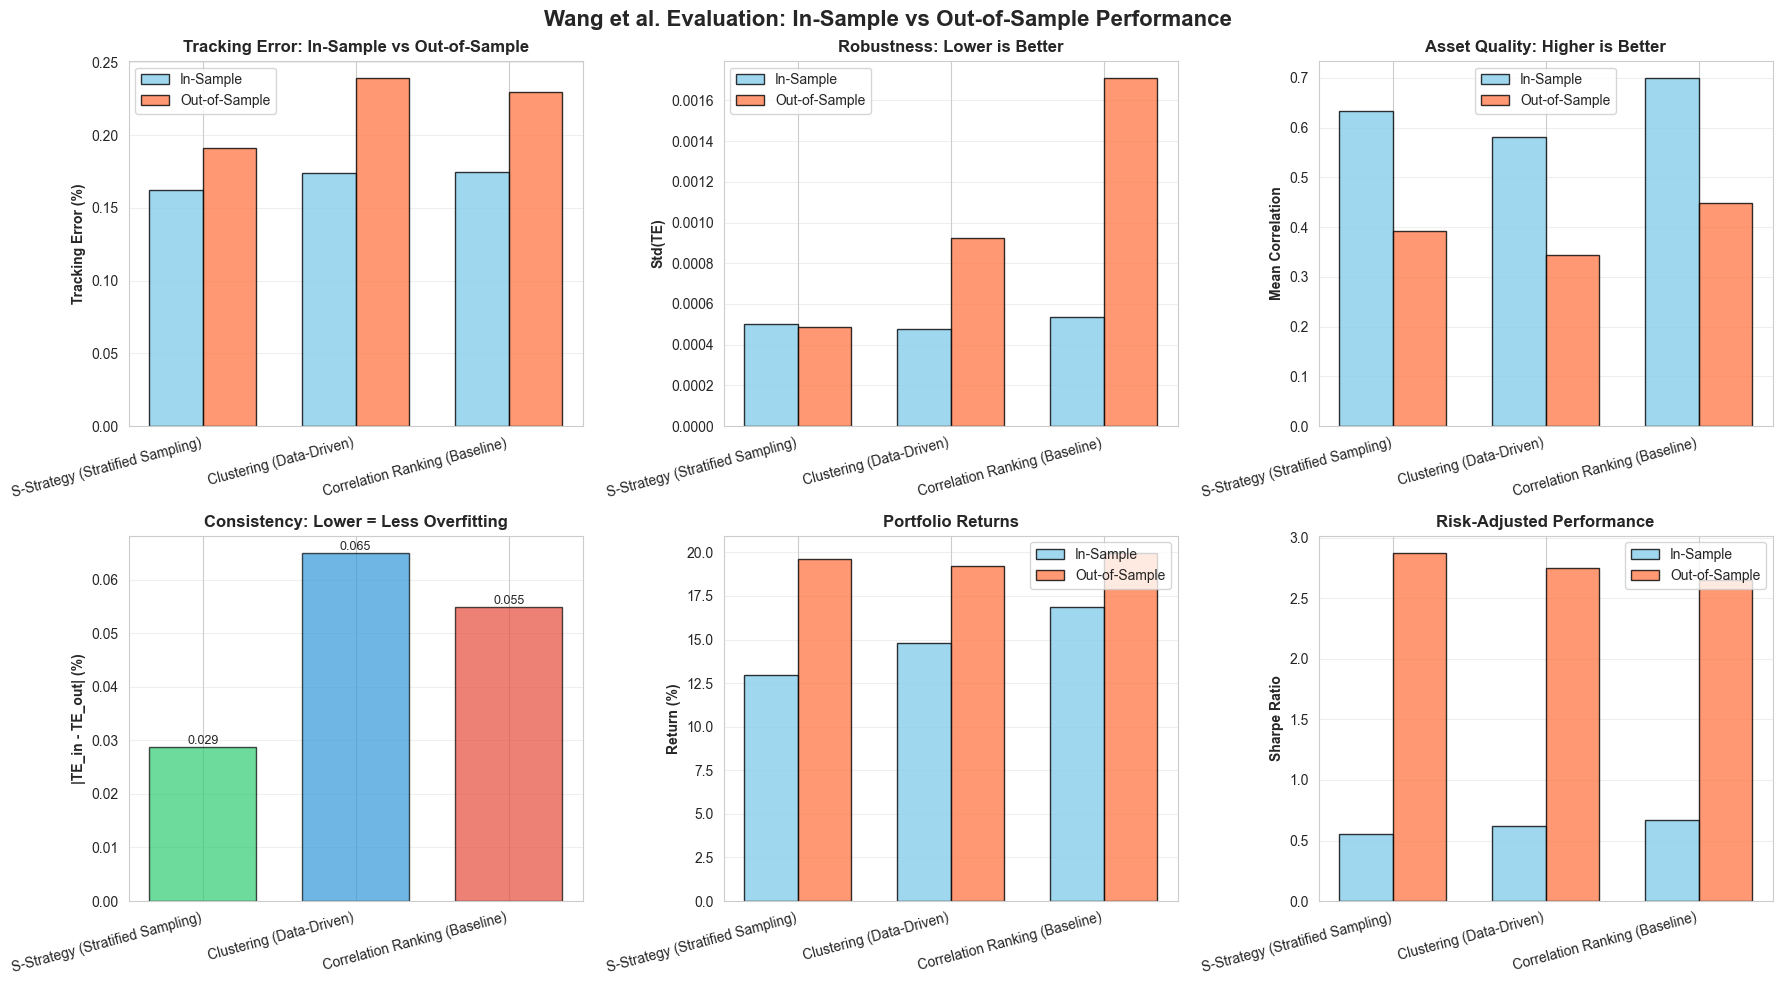


✓ Wang et al. evaluation visualization complete


In [21]:
# VISUALIZATION: IN-SAMPLE VS OUT-OF-SAMPLE COMPARISON
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Wang et al. Evaluation: In-Sample vs Out-of-Sample Performance', 
             fontsize=16, fontweight='bold')

strategies = wang_comparison_df.index.tolist()
colors = ['#2ecc71', '#3498db', '#e74c3c']

# 1. Tracking Error Comparison
ax = axes[0, 0]
x = np.arange(len(strategies))
width = 0.35
bars1 = ax.bar(x - width/2, wang_comparison_df['TE_in (%)'], width, 
               label='In-Sample', color='skyblue', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, wang_comparison_df['TE_out (%)'], width, 
               label='Out-of-Sample', color='coral', alpha=0.8, edgecolor='black')
ax.set_ylabel('Tracking Error (%)', fontweight='bold')
ax.set_title('Tracking Error: In-Sample vs Out-of-Sample', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(strategies, rotation=15, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 2. Robustness (Std_TE)
ax = axes[0, 1]
bars1 = ax.bar(x - width/2, wang_comparison_df['Std_TE_in'], width, 
               label='In-Sample', color='skyblue', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, wang_comparison_df['Std_TE_out'], width, 
               label='Out-of-Sample', color='coral', alpha=0.8, edgecolor='black')
ax.set_ylabel('Std(TE)', fontweight='bold')
ax.set_title('Robustness: Lower is Better', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(strategies, rotation=15, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 3. Mean Correlation
ax = axes[0, 2]
bars1 = ax.bar(x - width/2, wang_comparison_df['Mean_Corr_in'], width, 
               label='In-Sample', color='skyblue', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, wang_comparison_df['Mean_Corr_out'], width, 
               label='Out-of-Sample', color='coral', alpha=0.8, edgecolor='black')
ax.set_ylabel('Mean Correlation', fontweight='bold')
ax.set_title('Asset Quality: Higher is Better', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(strategies, rotation=15, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 4. Consistency (smaller = less overfitting)
ax = axes[1, 0]
bars = ax.bar(x, wang_comparison_df['Consistency'], width*2, 
              color=colors, alpha=0.7, edgecolor='black')
ax.set_ylabel('|TE_in - TE_out| (%)', fontweight='bold')
ax.set_title('Consistency: Lower = Less Overfitting', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(strategies, rotation=15, ha='right')
ax.grid(axis='y', alpha=0.3)
# Add value labels
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# 5. Returns Comparison
ax = axes[1, 1]
bars1 = ax.bar(x - width/2, wang_comparison_df['Return_in (%)'], width, 
               label='In-Sample', color='skyblue', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, wang_comparison_df['Return_out (%)'], width, 
               label='Out-of-Sample', color='coral', alpha=0.8, edgecolor='black')
ax.set_ylabel('Return (%)', fontweight='bold')
ax.set_title('Portfolio Returns', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(strategies, rotation=15, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 6. Sharpe Ratio
ax = axes[1, 2]
bars1 = ax.bar(x - width/2, wang_comparison_df['Sharpe_in'], width, 
               label='In-Sample', color='skyblue', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, wang_comparison_df['Sharpe_out'], width, 
               label='Out-of-Sample', color='coral', alpha=0.8, edgecolor='black')
ax.set_ylabel('Sharpe Ratio', fontweight='bold')
ax.set_title('Risk-Adjusted Performance', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(strategies, rotation=15, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Wang et al. evaluation visualization complete")

### 📊 Interpretation of Results

Compare your results to Wang et al.'s findings:

**Expected Patterns:**
1. **Tracking Error**: All models should achieve low TE_in (optimized on training data). TE_out shows generalization.
2. **Consistency**: Lower consistency (|TE_in - TE_out|) indicates less overfitting
3. **S-Strategy**: Should show moderate TE but good consistency (structured approach reduces overfitting)
4. **Correlation Ranking**: May show lowest TE_in but higher consistency (risk of overfitting to high correlations)
5. **Clustering**: Data-driven, behavior depends on market structure

**Red Flags:**
- TE_out >> TE_in: Severe overfitting
- Consistency > 2%: Model not generalizing well
- Mean_Corr_out << Mean_Corr_in: Asset quality degrades out-of-sample

**Good Signs:**
- TE_out ≈ TE_in: Good generalization
- Low Std_TE: Robust tracking
- High Mean_Corr: Quality asset selection

## Section 4.6: Multi-K Wang Evaluation

**Critical Analysis**: How does portfolio size K affect performance?

This section runs the **Wang et al. compliant evaluation** for multiple portfolio sizes:
K = 50, 75, 100, 125, 150, 175, 200

### Key Questions:
1. Does **TE_out decrease** with larger K? (more assets = better tracking)
2. Does **Consistency improve** with larger K? (less overfitting with more degrees of freedom)
3. Does **Mean_Corr decrease** with larger K? (diminishing returns in asset quality)
4. Which K provides the best **trade-off** between tracking error and number of assets?

### Expected Behavior (from Portfolio Theory):
- Larger K → Lower TE (more assets to replicate index)
- Larger K → Better diversification
- But: Diminishing returns beyond certain K
- Transaction costs increase with K (not modeled here)

In [22]:
# MULTI-K WANG EVALUATION
print("=" * 80)
print("MULTI-K WANG EVALUATION - PARADIGM 1")
print("Testing K = 50, 75, 100, 125, 150, 175, 200")
print("=" * 80)

# Define K values to test
k_values = [50, 75, 100, 125, 150, 175, 200]
multi_k_wang_results = []

for K in k_values:
    print(f"\n{'='*80}")
    print(f"K = {K}")
    print(f"{'='*80}")
    
    # Check feasibility
    if K > len(returns.columns):
        print(f"⚠️  Skipping K={K}: Only {len(returns.columns)} assets available")
        continue
    
    # Create new Wang engine for this K (same data split)
    wang_engine_k = WangBacktestEngine(
        returns=returns,
        index_returns=index_returns,
        correlation_matrix=correlation_matrix,
        train_ratio=0.7,
        slippage=0.001
    )
    
    # MODEL 1: STRATIFIED SAMPLING
    print(f"\n[1/3] S-Strategy (K={K})")
    model1_k = StratifiedSamplingModel(K=K, num_strata=10)
    opt1_k = PortfolioOptimizer()
    result1_k = wang_engine_k.backtest_strategy(
        selection_model=model1_k,
        optimizer=opt1_k,
        strategy_name=f"S-Strategy (K={K})",
        sector_mapping=sector_mapping
    )
    multi_k_wang_results.append(result1_k)
    
    # MODEL 2: CLUSTERING
    print(f"\n[2/3] Clustering (K={K})")
    model2_k = ClusteringModel(K=K, num_clusters=min(10, K))
    opt2_k = PortfolioOptimizer()
    result2_k = wang_engine_k.backtest_strategy(
        selection_model=model2_k,
        optimizer=opt2_k,
        strategy_name=f"Clustering (K={K})"
    )
    multi_k_wang_results.append(result2_k)
    
    # MODEL 3: CORRELATION RANKING
    print(f"\n[3/3] Correlation Ranking (K={K})")
    model3_k = CorrelationRankingModel(K=K)
    opt3_k = PortfolioOptimizer()
    result3_k = wang_engine_k.backtest_strategy(
        selection_model=model3_k,
        optimizer=opt3_k,
        strategy_name=f"Correlation Ranking (K={K})"
    )
    multi_k_wang_results.append(result3_k)
    
    print(f"\n✓ Completed K={K}")

print("\n" + "=" * 80)
print(f"MULTI-K EVALUATION COMPLETE: {len(multi_k_wang_results)} results")
print("=" * 80)

MULTI-K WANG EVALUATION - PARADIGM 1
Testing K = 50, 75, 100, 125, 150, 175, 200

K = 50
Data split:
  In-sample:     2024-03-28 to 2025-06-23 (309 days)
  Out-of-sample: 2025-06-24 to 2025-12-31 (133 days)

[1/3] S-Strategy (K=50)

BACKTESTING: S-Strategy (K=50)

[IN-SAMPLE PHASE]
1. Selecting assets...
Stratified Sampling: Selecting from 11 sectors
  Industrials: 8/8 assets
  Health Care: 7/7 assets
  Information Technology: 9/9 assets
  Utilities: 3/3 assets
  Financials: 7/7 assets
  Materials: 2/2 assets
  Consumer Discretionary: 5/5 assets
  Real Estate: 2/2 assets
  Communication Services: 2/2 assets
  Consumer Staples: 4/4 assets
  Energy: 1/1 assets
Total selected: 50 assets
   ✓ Selected 50 assets
2. Optimizing weights...
   ✓ Weights optimized (objective: 0.000816)
3. Computing in-sample metrics...
   ✓ IN-SAMPLE: TE=0.1625%, Std_TE=0.0005, Mean_Corr=0.6333, Return=12.94%

[OUT-OF-SAMPLE PHASE]
4. Computing out-of-sample metrics...
   ✓ OUT-OF-SAMPLE: TE=0.1912%, Std_TE=0.00

In [25]:
# Create comprehensive results DataFrame
multi_k_wang_data = []
for r in multi_k_wang_results:
    # Extract strategy name and K
    strategy_full = r['strategy_name']
    if 'K=' in strategy_full:
        strategy_base = strategy_full.split('(K=')[0].strip()
        K_val = r['num_assets']
    else:
        strategy_base = strategy_full
        K_val = r['num_assets']
    
    multi_k_wang_data.append({
        'Strategy': strategy_base,
        'K': K_val,
        'Mean_Corr_in': r['Mean_Corr_in'],
        'Mean_Corr_out': r['Mean_Corr_out'],
        'TE_in': r['TE_in'],
        'TE_out': r['TE_out'],
        'Std_TE_in': r['Std_TE_in'],
        'Std_TE_out': r['Std_TE_out'],
        'Consistency': r['Consistency'],
        'Return_in': r['Return_in'],
        'Return_out': r['Return_out'],
        'Sharpe_in': r['Sharpe_in'],
        'Sharpe_out': r['Sharpe_out'],
    })

multi_k_wang_df = pd.DataFrame(multi_k_wang_data)

# Display summary
print("\n" + "=" * 80)
print("MULTI-K WANG RESULTS SUMMARY")
print("=" * 80)
print(multi_k_wang_df.to_string(index=False))

# Save to CSV
multi_k_wang_df.to_csv(export_dir / 'multi_k_wang_evaluation.csv', index=False)
print(f"\n✓ Results saved to {export_dir / 'multi_k_wang_evaluation.csv'}")

# Create pivot tables for key metrics
print("\n" + "=" * 80)
print("TE_OUT BY K AND MODEL")
print("=" * 80)
pivot_te_out = multi_k_wang_df.pivot(index='K', columns='Strategy', values='TE_out')
print(pivot_te_out.to_string())

print("\n" + "=" * 80)
print("CONSISTENCY BY K AND MODEL")
print("=" * 80)
pivot_consistency = multi_k_wang_df.pivot(index='K', columns='Strategy', values='Consistency')
print(pivot_consistency.to_string())

print("\n" + "=" * 80)
print("MEAN_CORR_OUT BY K AND MODEL")
print("=" * 80)
pivot_corr = multi_k_wang_df.pivot(index='K', columns='Strategy', values='Mean_Corr_out')
print(pivot_corr.to_string())

multi_k_wang_df


MULTI-K WANG RESULTS SUMMARY
           Strategy   K  Mean_Corr_in  Mean_Corr_out    TE_in   TE_out  Std_TE_in  Std_TE_out  Consistency  Return_in  Return_out  Sharpe_in  Sharpe_out
         S-Strategy  50      0.633288       0.391999 0.162511 0.191220   0.000502    0.000487     0.028709  12.942553   19.626025   0.556946    2.873191
         Clustering  50      0.581642       0.343466 0.174217 0.239180   0.000480    0.000925     0.064963  14.821996   19.203867   0.622502    2.746500
Correlation Ranking  50      0.699936       0.448787 0.174867 0.229796   0.000538    0.001710     0.054929  16.876373   19.966207   0.666215    2.650681
         S-Strategy  75      0.618068       0.386908 0.095132 0.134980   0.000130    0.000284     0.039848  14.738593   22.577592   0.615871    3.220242
         Clustering  75      0.563407       0.317424 0.127701 0.180069   0.000282    0.000523     0.052367  15.802821   23.686044   0.656209    3.372281
Correlation Ranking  75      0.675483       0.437429

,Strategy,K,Mean_Corr_in,Mean_Corr_out,TE_in,TE_out,Std_TE_in,Std_TE_out,Consistency,Return_in,Return_out,Sharpe_in,Sharpe_out
0,S-Strategy,50,0.633288,0.391999,0.162511,0.191220,0.000502,0.000487,0.028709,12.942553,19.626025,0.556946,2.873191
1,Clustering,50,0.581642,0.343466,0.174217,0.239180,0.000480,0.000925,0.064963,14.821996,19.203867,0.622502,2.746500
2,Correlation Ranking,50,0.699936,0.448787,0.174867,0.229796,0.000538,0.001710,0.054929,16.876373,19.966207,0.666215,2.650681
3,S-Strategy,75,0.618068,0.386908,0.095132,0.134980,0.000130,0.000284,0.039848,14.738593,22.577592,0.615871,3.220242
4,Clustering,75,0.563407,0.317424,0.127701,0.180069,0.000282,0.000523,0.052367,15.802821,23.686044,0.656209,3.372281
5,Correlation Ranking,75,0.675483,0.437429,0.151480,0.220747,0.000437,0.001380,0.069267,17.821712,21.686459,0.699311,2.903763
6,S-Strategy,100,0.589125,0.357216,0.081185,0.123002,0.000101,0.000245,0.041817,15.992855,22.862442,0.657600,3.270597
7,Clustering,100,0.551806,0.311499,0.120018,0.169105,0.000237,0.000460,0.049087,15.610656,23.644407,0.650787,3.381825
8,Correlation Ranking,100,0.652872,0.414957,0.118403,0.145154,0.000238,0.000395,0.026751,17.911179,21.271717,0.706396,2.952302
9,S-Strategy,125,0.568568,0.337722,0.071626,0.103177,0.000082,0.000168,0.031551,15.409637,21.541838,0.639477,3.133328


In [26]:
# EXPORT PORTFOLIO COMPOSITIONS FOR ALL K VALUES
# Save selected assets, benchmark weights, and portfolio weights for each model and K

print("=" * 80)
print("EXPORTING PORTFOLIO COMPOSITIONS - PARADIGM 1")
print("=" * 80)

# Create directory for portfolio compositions
compositions_dir = Path("./results/portfolio_compositions")
compositions_dir.mkdir(exist_ok=True, parents=True)

# Get benchmark market cap weights (normalized)
if hasattr(data_handler, 'market_caps') and data_handler.market_caps is not None:
    # Use the last date's market caps (DataFrame with dates as index, tickers as columns)
    if isinstance(data_handler.market_caps, pd.DataFrame):
        benchmark_market_caps = data_handler.market_caps.iloc[-1, :]  # Last row, all columns
        benchmark_weights_all = benchmark_market_caps / benchmark_market_caps.sum()
    elif isinstance(data_handler.market_caps, pd.Series):
        benchmark_weights_all = data_handler.market_caps / data_handler.market_caps.sum()
    else:
        print("⚠ Market cap data format unexpected, using equal weights")
        benchmark_weights_all = pd.Series(1.0 / len(returns.columns), index=returns.columns)
else:
    print("⚠ Market cap data not available, using equal weights for benchmark")
    benchmark_weights_all = pd.Series(1.0 / len(returns.columns), index=returns.columns)

# Ensure benchmark_weights_all is a Series indexed by ticker
if not isinstance(benchmark_weights_all, pd.Series):
    print("⚠ Converting benchmark weights to Series")
    benchmark_weights_all = pd.Series(1.0 / len(returns.columns), index=returns.columns)

# Map model names
model_configs = [
    ("Stratified_Sampling", StratifiedSamplingModel, {"num_strata": 10}),
    ("Clustering", ClusteringModel, {"num_clusters": 10}),
    ("Correlation_Ranking", CorrelationRankingModel, {})
]

compositions_saved = 0

for K in k_values:
    if K > len(returns.columns):
        continue
    
    print(f"\n[K={K}] Saving portfolio compositions...")
    
    for model_name, ModelClass, model_params in model_configs:
        # Update num_clusters for clustering if needed
        if model_name == "Clustering":
            model_params["num_clusters"] = min(10, K)
        
        # Initialize model
        if model_name == "Stratified_Sampling":
            model = ModelClass(K=K, **model_params)
            selected_assets = model.select(
                returns=returns,
                correlation_matrix=correlation_matrix,
                sector_mapping=sector_mapping
            )
        else:
            model = ModelClass(K=K, **model_params)
            selected_assets = model.select(
                returns=returns,
                correlation_matrix=correlation_matrix
            )
        
        # Optimize weights
        optimizer = PortfolioOptimizer()
        selected_returns = returns[selected_assets]
        portfolio_weights_array = optimizer.optimize(selected_returns, index_returns)
        
        # Create DataFrame with asset, benchmark weight, portfolio weight
        composition_df = pd.DataFrame({
            'Asset': selected_assets,
            'Benchmark_Weight': [benchmark_weights_all.loc[asset] if asset in benchmark_weights_all.index else 0.0 
                                 for asset in selected_assets],
            'Portfolio_Weight': portfolio_weights_array
        })
        
        # Sort by portfolio weight (descending)
        composition_df = composition_df.sort_values('Portfolio_Weight', ascending=False)
        
        # Add summary statistics
        composition_df.loc['TOTAL'] = ['TOTAL', 
                                        composition_df['Benchmark_Weight'].sum(),
                                        composition_df['Portfolio_Weight'].sum()]
        
        # Save to CSV
        filename = f"P1_{model_name}_K{K}_composition.csv"
        filepath = compositions_dir / filename
        composition_df.to_csv(filepath, index=False)
        compositions_saved += 1
        
        print(f"  ✓ {model_name}: {len(selected_assets)} assets → {filename}")

print(f"\n{'='*80}")
print(f"✓ SAVED {compositions_saved} PORTFOLIO COMPOSITION FILES")
print(f"✓ Location: {compositions_dir.absolute()}")
print(f"{'='*80}")

EXPORTING PORTFOLIO COMPOSITIONS - PARADIGM 1

[K=50] Saving portfolio compositions...
Stratified Sampling: Selecting from 11 sectors
  Industrials: 8/8 assets
  Health Care: 7/7 assets
  Information Technology: 9/9 assets
  Utilities: 3/3 assets
  Financials: 7/7 assets
  Materials: 2/2 assets
  Consumer Discretionary: 5/5 assets
  Real Estate: 2/2 assets
  Communication Services: 2/2 assets
  Consumer Staples: 4/4 assets
  Energy: 1/1 assets
Total selected: 50 assets
  ✓ Stratified_Sampling: 50 assets → P1_Stratified_Sampling_K50_composition.csv
Clustering: Performing K-means with 10 clusters on return features
  Cluster 0: 39 assets → selected 6
  Cluster 1: 69 assets → selected 11
  Cluster 2: 1 assets → selected 1
  Cluster 3: 12 assets → selected 1
  Cluster 4: 42 assets → selected 6
  Cluster 5: 46 assets → selected 7
  Cluster 6: 20 assets → selected 3
  Cluster 7: 1 assets → selected 1
  Cluster 8: 71 assets → selected 11
  Cluster 9: 2 assets → selected 1
  Added 2 additional

### 📁 Portfolio Composition Files

The CSV files saved in `./results/portfolio_compositions/` contain:

**Columns:**
- `Asset`: Ticker symbol of selected asset
- `Benchmark_Weight`: Market-cap weight in the S&P 500 index (~500 stocks)
- `Portfolio_Weight`: Optimized weight in the replication portfolio (K assets)

**Naming Convention:**
- `P1_{Model}_{K}{Value}_composition.csv`
- Example: `P1_Stratified_Sampling_K50_composition.csv`

**Models:**
- Stratified_Sampling (S-Strategy)
- Clustering
- Correlation_Ranking

**K Values:** 50, 75, 100, 125, 150, 175, 200

**Summary Row:**
- The last row ('TOTAL') shows sum of weights
- Portfolio weights should sum to 1.0
- Benchmark weights show % of S&P 500 captured by selected assets

S-Strategy: TE_out improvement from K=50 to K=200: 70.6%
Clustering: TE_out improvement from K=50 to K=200: 79.3%
Correlation Ranking: TE_out improvement from K=50 to K=200: 60.3%


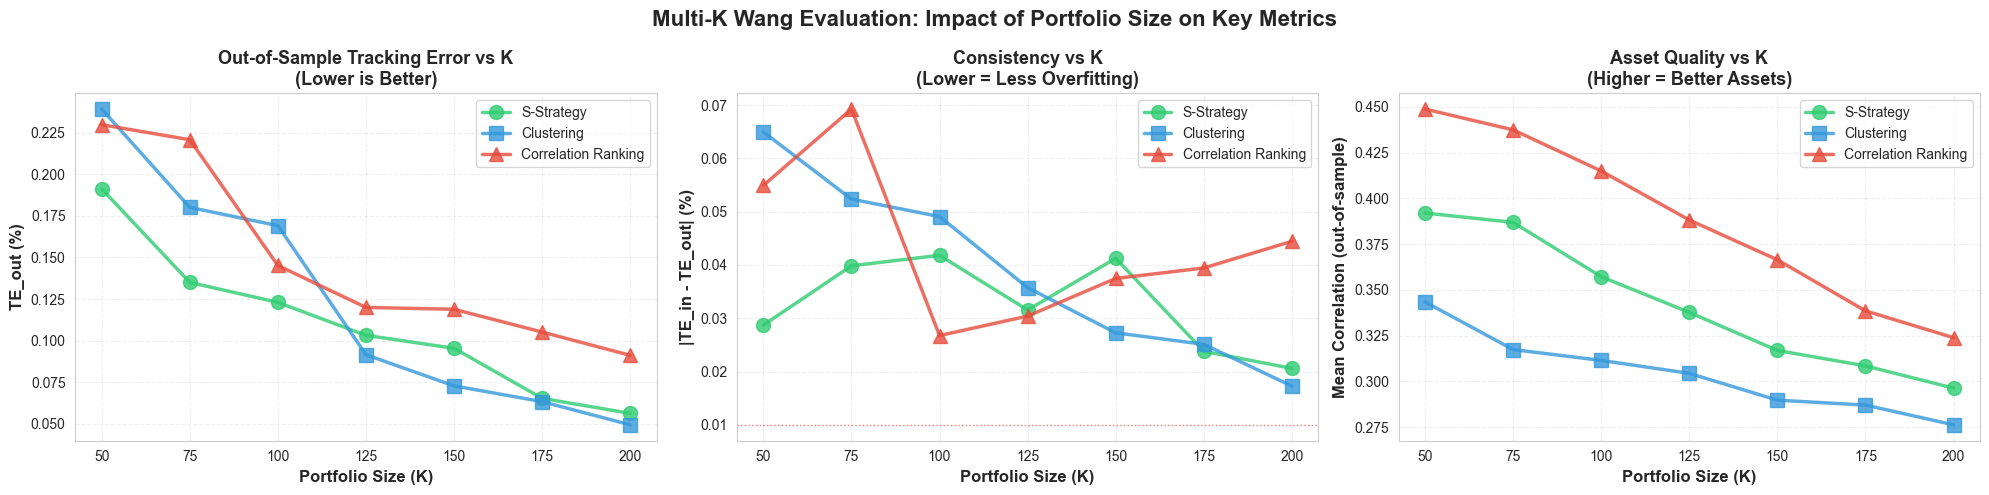


✓ Multi-K Wang visualization complete


In [27]:
# MULTI-K WANG VISUALIZATION: THE THREE KEY PLOTS
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Multi-K Wang Evaluation: Impact of Portfolio Size on Key Metrics', 
             fontsize=16, fontweight='bold')

strategies = multi_k_wang_df['Strategy'].unique()
colors = {'S-Strategy': '#2ecc71', 'Clustering': '#3498db', 'Correlation Ranking': '#e74c3c'}
markers = {'S-Strategy': 'o', 'Clustering': 's', 'Correlation Ranking': '^'}

# 1. TE_out vs K (MOST IMPORTANT: Generalization Performance)
ax = axes[0]
for strategy in strategies:
    strategy_data = multi_k_wang_df[multi_k_wang_df['Strategy'] == strategy]
    ax.plot(strategy_data['K'], strategy_data['TE_out'], 
            marker=markers[strategy], linewidth=2.5, markersize=10,
            label=strategy, color=colors[strategy], alpha=0.8)
ax.set_xlabel('Portfolio Size (K)', fontweight='bold', fontsize=12)
ax.set_ylabel('TE_out (%)', fontweight='bold', fontsize=12)
ax.set_title('Out-of-Sample Tracking Error vs K\n(Lower is Better)', fontweight='bold', fontsize=13)
ax.legend(loc='best', fontsize=10)
ax.grid(alpha=0.3, linestyle='--')
ax.set_xticks(k_values)

# Annotate trend
for strategy in strategies:
    strategy_data = multi_k_wang_df[multi_k_wang_df['Strategy'] == strategy]
    te_50 = strategy_data[strategy_data['K'] == 50]['TE_out'].values[0]
    te_200 = strategy_data[strategy_data['K'] == 200]['TE_out'].values[0] if len(strategy_data[strategy_data['K'] == 200]) > 0 else te_50
    improvement = ((te_50 - te_200) / te_50 * 100) if te_200 < te_50 else 0
    print(f"{strategy}: TE_out improvement from K=50 to K=200: {improvement:.1f}%")

# 2. Consistency vs K (OVERFITTING MEASURE)
ax = axes[1]
for strategy in strategies:
    strategy_data = multi_k_wang_df[multi_k_wang_df['Strategy'] == strategy]
    ax.plot(strategy_data['K'], strategy_data['Consistency'], 
            marker=markers[strategy], linewidth=2.5, markersize=10,
            label=strategy, color=colors[strategy], alpha=0.8)
ax.set_xlabel('Portfolio Size (K)', fontweight='bold', fontsize=12)
ax.set_ylabel('|TE_in - TE_out| (%)', fontweight='bold', fontsize=12)
ax.set_title('Consistency vs K\n(Lower = Less Overfitting)', fontweight='bold', fontsize=13)
ax.legend(loc='best', fontsize=10)
ax.grid(alpha=0.3, linestyle='--')
ax.set_xticks(k_values)
ax.axhline(y=0.01, color='red', linestyle=':', linewidth=1, alpha=0.5, label='Target < 1%')

# 3. Mean_Corr_out vs K (ASSET QUALITY)
ax = axes[2]
for strategy in strategies:
    strategy_data = multi_k_wang_df[multi_k_wang_df['Strategy'] == strategy]
    ax.plot(strategy_data['K'], strategy_data['Mean_Corr_out'], 
            marker=markers[strategy], linewidth=2.5, markersize=10,
            label=strategy, color=colors[strategy], alpha=0.8)
ax.set_xlabel('Portfolio Size (K)', fontweight='bold', fontsize=12)
ax.set_ylabel('Mean Correlation (out-of-sample)', fontweight='bold', fontsize=12)
ax.set_title('Asset Quality vs K\n(Higher = Better Assets)', fontweight='bold', fontsize=13)
ax.legend(loc='best', fontsize=10)
ax.grid(alpha=0.3, linestyle='--')
ax.set_xticks(k_values)

plt.tight_layout()
plt.show()

print("\n✓ Multi-K Wang visualization complete")

In [28]:
# ADDITIONAL ANALYSIS: EFFICIENCY FRONTIER
# Which K gives best trade-off between TE_out and number of assets?

print("=" * 80)
print("EFFICIENCY ANALYSIS: OPTIMAL K SELECTION")
print("=" * 80)

for strategy in strategies:
    strategy_data = multi_k_wang_df[multi_k_wang_df['Strategy'] == strategy]
    
    print(f"\n{strategy}:")
    print("-" * 60)
    
    # Find best K for different criteria
    best_te_out = strategy_data.loc[strategy_data['TE_out'].idxmin()]
    best_consistency = strategy_data.loc[strategy_data['Consistency'].idxmin()]
    best_corr = strategy_data.loc[strategy_data['Mean_Corr_out'].idxmax()]
    
    print(f"  Best TE_out:      K={best_te_out['K']:.0f}, TE_out={best_te_out['TE_out']:.4f}%")
    print(f"  Best Consistency: K={best_consistency['K']:.0f}, Consistency={best_consistency['Consistency']:.4f}%")
    print(f"  Best Mean_Corr:   K={best_corr['K']:.0f}, Mean_Corr={best_corr['Mean_Corr_out']:.4f}")
    
    # Compute "efficiency score": normalized TE_out / K
    # Lower is better (lower TE with fewer assets)
    strategy_data_copy = strategy_data.copy()
    strategy_data_copy['Efficiency'] = strategy_data_copy['TE_out'] / (strategy_data_copy['K'] / 50)
    best_efficiency = strategy_data_copy.loc[strategy_data_copy['Efficiency'].idxmin()]
    print(f"  Best Efficiency:  K={best_efficiency['K']:.0f} (TE_out={best_efficiency['TE_out']:.4f}%, normalized)")

print("\n" + "=" * 80)
print("KEY INSIGHTS")
print("=" * 80)

# Overall best K across all models
overall_best_k = multi_k_wang_df.groupby('K')['TE_out'].mean().idxmin()
overall_best_te = multi_k_wang_df.groupby('K')['TE_out'].mean().min()
print(f"✓ Overall best K (average TE_out): K={overall_best_k:.0f} with TE_out={overall_best_te:.4f}%")

# Diminishing returns analysis
te_reduction_50_100 = (multi_k_wang_df[multi_k_wang_df['K']==50]['TE_out'].mean() - 
                       multi_k_wang_df[multi_k_wang_df['K']==100]['TE_out'].mean())
te_reduction_150_200 = (multi_k_wang_df[multi_k_wang_df['K']==150]['TE_out'].mean() - 
                        multi_k_wang_df[multi_k_wang_df['K']==200]['TE_out'].mean())

print(f"✓ TE reduction K=50→100:  {te_reduction_50_100:.4f}% (50 assets added)")
print(f"✓ TE reduction K=150→200: {te_reduction_150_200:.4f}% (50 assets added)")
print(f"✓ Diminishing returns: {'YES' if te_reduction_150_200 < te_reduction_50_100 else 'NO'}")

print("=" * 80)

EFFICIENCY ANALYSIS: OPTIMAL K SELECTION

S-Strategy:
------------------------------------------------------------
  Best TE_out:      K=200, TE_out=0.0563%
  Best Consistency: K=200, Consistency=0.0206%
  Best Mean_Corr:   K=50, Mean_Corr=0.3920
  Best Efficiency:  K=200 (TE_out=0.0563%, normalized)

Clustering:
------------------------------------------------------------
  Best TE_out:      K=200, TE_out=0.0494%
  Best Consistency: K=200, Consistency=0.0173%
  Best Mean_Corr:   K=50, Mean_Corr=0.3435
  Best Efficiency:  K=200 (TE_out=0.0494%, normalized)

Correlation Ranking:
------------------------------------------------------------
  Best TE_out:      K=200, TE_out=0.0912%
  Best Consistency: K=100, Consistency=0.0268%
  Best Mean_Corr:   K=50, Mean_Corr=0.4488
  Best Efficiency:  K=200 (TE_out=0.0912%, normalized)

KEY INSIGHTS
✓ Overall best K (average TE_out): K=200 with TE_out=0.0656%
✓ TE reduction K=50→100:  0.0743% (50 assets added)
✓ TE reduction K=150→200: 0.0301% (50 as

### 📊 Multi-K Wang Analysis Interpretation

**What to Look For:**

1. **TE_out vs K Plot**:
   - Should **decrease** as K increases (more assets = better tracking)
   - Look for diminishing returns: improvement slows down at higher K
   - Compare models: Does one consistently outperform across all K?

2. **Consistency vs K Plot**:
   - Should **decrease** or stay flat as K increases
   - Lower consistency = less overfitting
   - If consistency increases with K, model is overfitting more with complexity

3. **Mean_Corr_out vs K Plot**:
   - Typically **decreases** as K increases (diminishing quality)
   - At K=50: selecting top 50 correlated assets
   - At K=200: forced to include lower-correlation assets

**Decision Framework for Optimal K**:
- **K too small** (K=50): Higher TE, but simpler portfolio
- **K too large** (K=200): Lower TE, but transaction costs, complexity
- **Optimal K**: Elbow point where TE reduction slows down

**For Your Thesis**:
- Use these plots to justify your choice of K
- Discuss trade-off between tracking error and portfolio complexity
- Compare Wang evaluation (proper) vs simple backtest (Section 4.6 old)

## Section 4.7: Simple Multi-K Backtest (For Comparison Only - Not Thesis Quality)

⚠️ **WARNING**: This section uses the OLD backtest method (no train/test split).
**Do NOT use these results for your thesis.** This is only for comparison to show the difference.

Test the impact of portfolio size by running backtests with K = 50, 75, 100, 125, 150, 175, 200.

In [29]:
# SIMPLE MULTI-K BACKTEST (OLD METHOD - FOR COMPARISON ONLY)
print("=" * 80)
print("MULTI-K BACKTEST ANALYSIS")
print("Testing portfolio sizes: K = 50, 75, 100, 125, 150, 175, 200")
print("=" * 80)

# Define K values to test
k_values = [50, 75, 100, 125, 150, 175, 200]
multi_k_results = []

for K in k_values:
    print(f"\n{'='*60}")
    print(f"TESTING K = {K}")
    print(f"{'='*60}")
    
    # Check feasibility
    if K > len(returns.columns):
        print(f"⚠️  Skipping K={K}: Only {len(returns.columns)} assets available")
        continue
    
    # Model 1: Stratified Sampling
    print(f"1. Stratified Sampling...")
    model1 = StratifiedSamplingModel(K=K, num_strata=10)
    assets1 = model1.select(returns=returns, correlation_matrix=correlation_matrix, sector_mapping=sector_mapping)
    
    # Model 2: Clustering
    print(f"2. Clustering...")
    model2 = ClusteringModel(K=K, num_clusters=min(10, K))
    assets2 = model2.select(returns=returns, correlation_matrix=correlation_matrix)
    
    # Model 3: Correlation Ranking
    print(f"3. Correlation Ranking...")
    model3 = CorrelationRankingModel(K=K)
    assets3 = model3.select(returns=returns, correlation_matrix=correlation_matrix)
    
    # Optimize weights
    print(f"4. Optimizing...")
    opt1 = PortfolioOptimizer()
    weights1 = opt1.optimize(returns[assets1], index_returns)
    
    opt2 = PortfolioOptimizer()
    weights2 = opt2.optimize(returns[assets2], index_returns)
    
    opt3 = PortfolioOptimizer()
    weights3 = opt3.optimize(returns[assets3], index_returns)
    
    # Backtest
    print(f"5. Backtesting...")
    result1 = backtest_engine.backtest(assets1, weights1)
    result2 = backtest_engine.backtest(assets2, weights2)
    result3 = backtest_engine.backtest(assets3, weights3)
    
    # Store results
    for model_name, result, assets in [('Stratified Sampling', result1, assets1),
                                        ('Clustering', result2, assets2),
                                        ('Correlation Ranking', result3, assets3)]:
        multi_k_results.append({
            'K': K,
            'Model': model_name,
            'Return': result['portfolio_return'],
            'Tracking_Error': result['tracking_error'],
            'Sharpe': result['sharpe_ratio'],
            'Max_Drawdown': result['max_drawdown'],
            'Avg_Correlation': correlation_matrix[correlation_matrix.index.isin(assets)].mean()
        })
    
    print(f"   ✓ K={K} complete")

# Create results DataFrame
multi_k_df = pd.DataFrame(multi_k_results)

print("\n" + "=" * 80)
print("MULTI-K RESULTS SUMMARY")
print("=" * 80)
print(multi_k_df.to_string(index=False))

# Save results
multi_k_df.to_csv(export_dir / 'multi_k_backtest_results.csv', index=False)
print(f"\n✓ Results saved to {export_dir / 'multi_k_backtest_results.csv'}")

# Pivot tables
print("\n" + "=" * 80)
print("TRACKING ERROR BY K AND MODEL")
print("=" * 80)
pivot_te = multi_k_df.pivot(index='K', columns='Model', values='Tracking_Error')
print(pivot_te.to_string())

print("\n" + "=" * 80)
print("PORTFOLIO RETURN BY K AND MODEL")
print("=" * 80)
pivot_ret = multi_k_df.pivot(index='K', columns='Model', values='Return')
print(pivot_ret.to_string())

# Analysis
print("\n" + "=" * 80)
print("KEY INSIGHTS")
print("=" * 80)
best_row = multi_k_df.loc[multi_k_df['Tracking_Error'].idxmin()]
print(f"✓ Best tracking error: {best_row['Tracking_Error']:.4f}% with {best_row['Model']} at K={best_row['K']}")

te_by_k = multi_k_df.groupby('K')['Tracking_Error'].mean()
print(f"✓ Average tracking error trend: {te_by_k.iloc[0]:.2f}% (K={k_values[0]}) → {te_by_k.iloc[-1]:.2f}% (K={k_values[-1]})")
print("=" * 80)

MULTI-K BACKTEST ANALYSIS
Testing portfolio sizes: K = 50, 75, 100, 125, 150, 175, 200

TESTING K = 50
1. Stratified Sampling...
Stratified Sampling: Selecting from 11 sectors
  Industrials: 8/8 assets
  Health Care: 7/7 assets
  Information Technology: 9/9 assets
  Utilities: 3/3 assets
  Financials: 7/7 assets
  Materials: 2/2 assets
  Consumer Discretionary: 5/5 assets
  Real Estate: 2/2 assets
  Communication Services: 2/2 assets
  Consumer Staples: 4/4 assets
  Energy: 1/1 assets
Total selected: 50 assets
2. Clustering...
Clustering: Performing K-means with 10 clusters on return features
  Cluster 0: 39 assets → selected 6
  Cluster 1: 69 assets → selected 11
  Cluster 2: 1 assets → selected 1
  Cluster 3: 12 assets → selected 1
  Cluster 4: 42 assets → selected 6
  Cluster 5: 46 assets → selected 7
  Cluster 6: 20 assets → selected 3
  Cluster 7: 1 assets → selected 1
  Cluster 8: 71 assets → selected 11
  Cluster 9: 2 assets → selected 1
  Added 2 additional assets to reach K=50

Visualizing multi-K results...


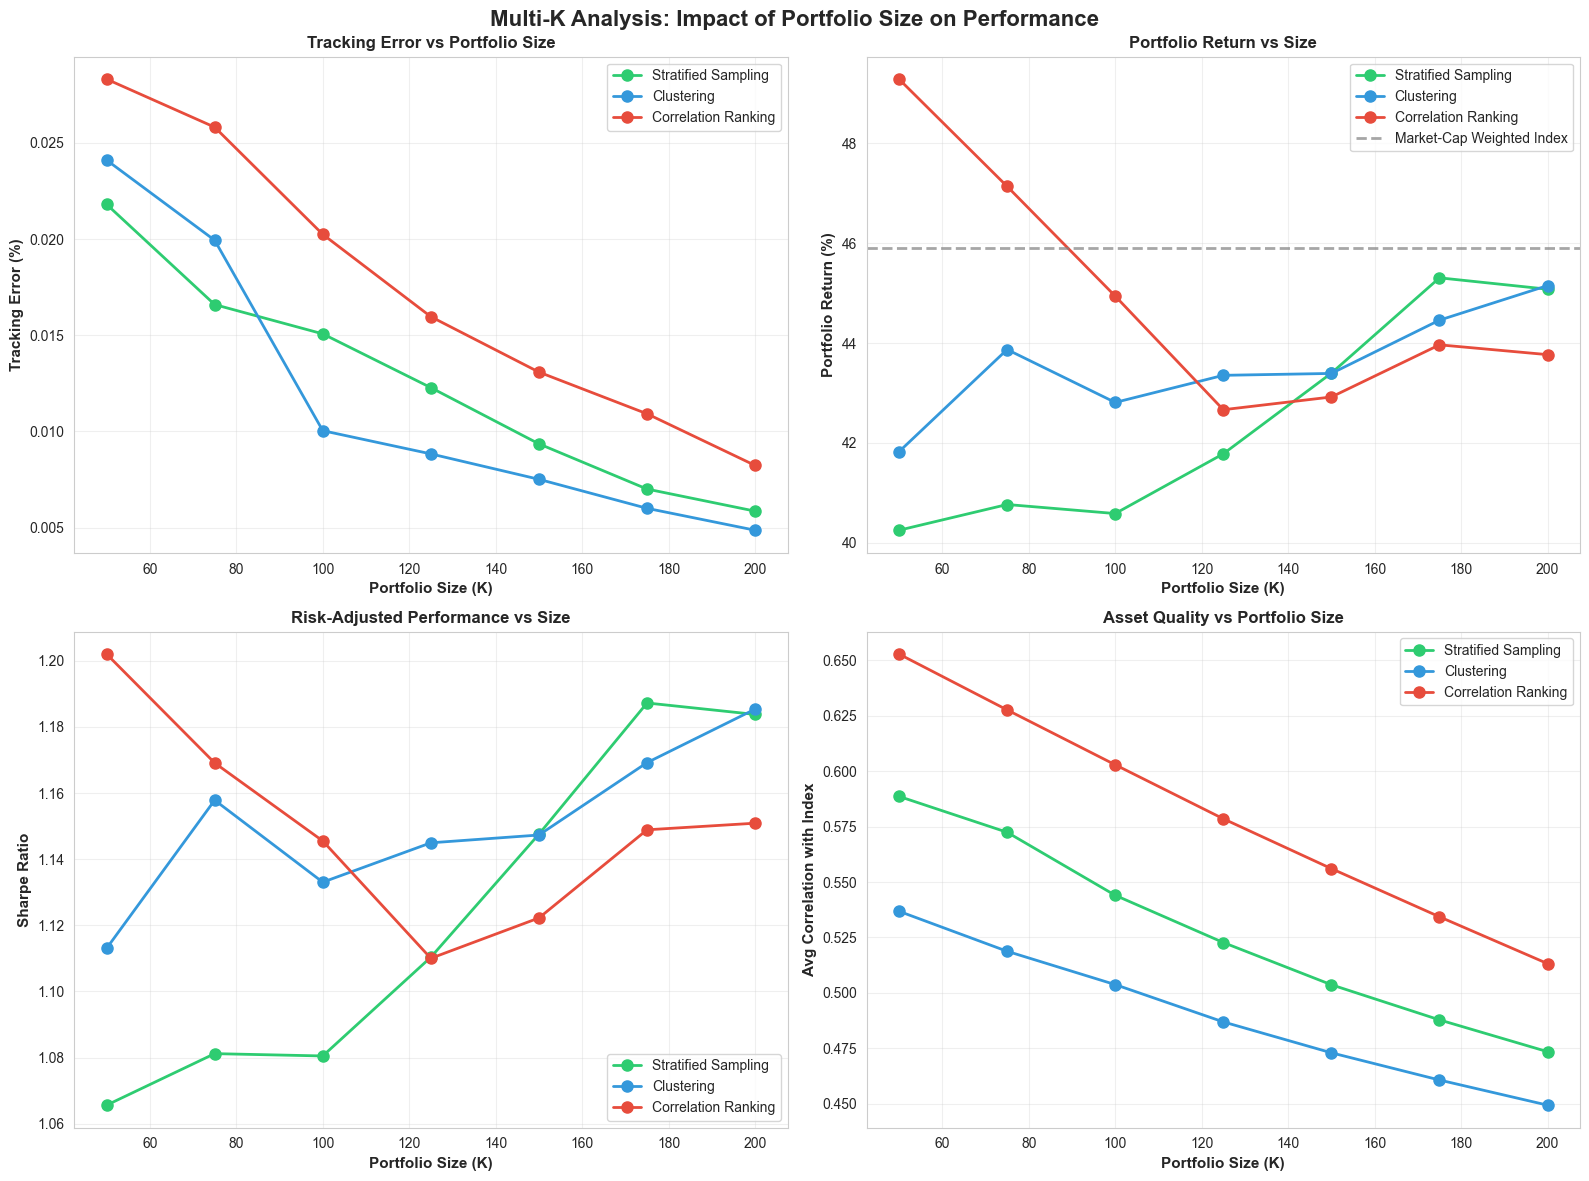


✓ Multi-K visualization complete


In [30]:
# MULTI-K VISUALIZATION
print("Visualizing multi-K results...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Multi-K Analysis: Impact of Portfolio Size on Performance', fontsize=16, fontweight='bold')

models = multi_k_df['Model'].unique()
colors = {'Stratified Sampling': '#2ecc71', 'Clustering': '#3498db', 'Correlation Ranking': '#e74c3c'}

# 1. Tracking Error vs K
ax = axes[0, 0]
for model in models:
    model_data = multi_k_df[multi_k_df['Model'] == model]
    ax.plot(model_data['K'], model_data['Tracking_Error'], 
            marker='o', linewidth=2, label=model, color=colors[model], markersize=8)
ax.set_xlabel('Portfolio Size (K)', fontweight='bold', fontsize=11)
ax.set_ylabel('Tracking Error (%)', fontweight='bold', fontsize=11)
ax.set_title('Tracking Error vs Portfolio Size', fontweight='bold', fontsize=12)
ax.legend(loc='best')
ax.grid(alpha=0.3)

# 2. Portfolio Return vs K
ax = axes[0, 1]
for model in models:
    model_data = multi_k_df[multi_k_df['Model'] == model]
    ax.plot(model_data['K'], model_data['Return'], 
            marker='o', linewidth=2, label=model, color=colors[model], markersize=8)
ax.axhline(y=result_sp500['portfolio_return'], color='gray', linestyle='--', 
           linewidth=2, label='Market-Cap Weighted Index', alpha=0.7)
ax.set_xlabel('Portfolio Size (K)', fontweight='bold', fontsize=11)
ax.set_ylabel('Portfolio Return (%)', fontweight='bold', fontsize=11)
ax.set_title('Portfolio Return vs Size', fontweight='bold', fontsize=12)
ax.legend(loc='best')
ax.grid(alpha=0.3)

# 3. Sharpe Ratio vs K
ax = axes[1, 0]
for model in models:
    model_data = multi_k_df[multi_k_df['Model'] == model]
    ax.plot(model_data['K'], model_data['Sharpe'], 
            marker='o', linewidth=2, label=model, color=colors[model], markersize=8)
ax.set_xlabel('Portfolio Size (K)', fontweight='bold', fontsize=11)
ax.set_ylabel('Sharpe Ratio', fontweight='bold', fontsize=11)
ax.set_title('Risk-Adjusted Performance vs Size', fontweight='bold', fontsize=12)
ax.legend(loc='best')
ax.grid(alpha=0.3)

# 4. Average Correlation vs K
ax = axes[1, 1]
for model in models:
    model_data = multi_k_df[multi_k_df['Model'] == model]
    ax.plot(model_data['K'], model_data['Avg_Correlation'], 
            marker='o', linewidth=2, label=model, color=colors[model], markersize=8)
ax.set_xlabel('Portfolio Size (K)', fontweight='bold', fontsize=11)
ax.set_ylabel('Avg Correlation with Index', fontweight='bold', fontsize=11)
ax.set_title('Asset Quality vs Portfolio Size', fontweight='bold', fontsize=12)
ax.legend(loc='best')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Multi-K visualization complete")

## Section 5: Visualizations

Key performance metrics, weight distributions, and correlation comparisons.

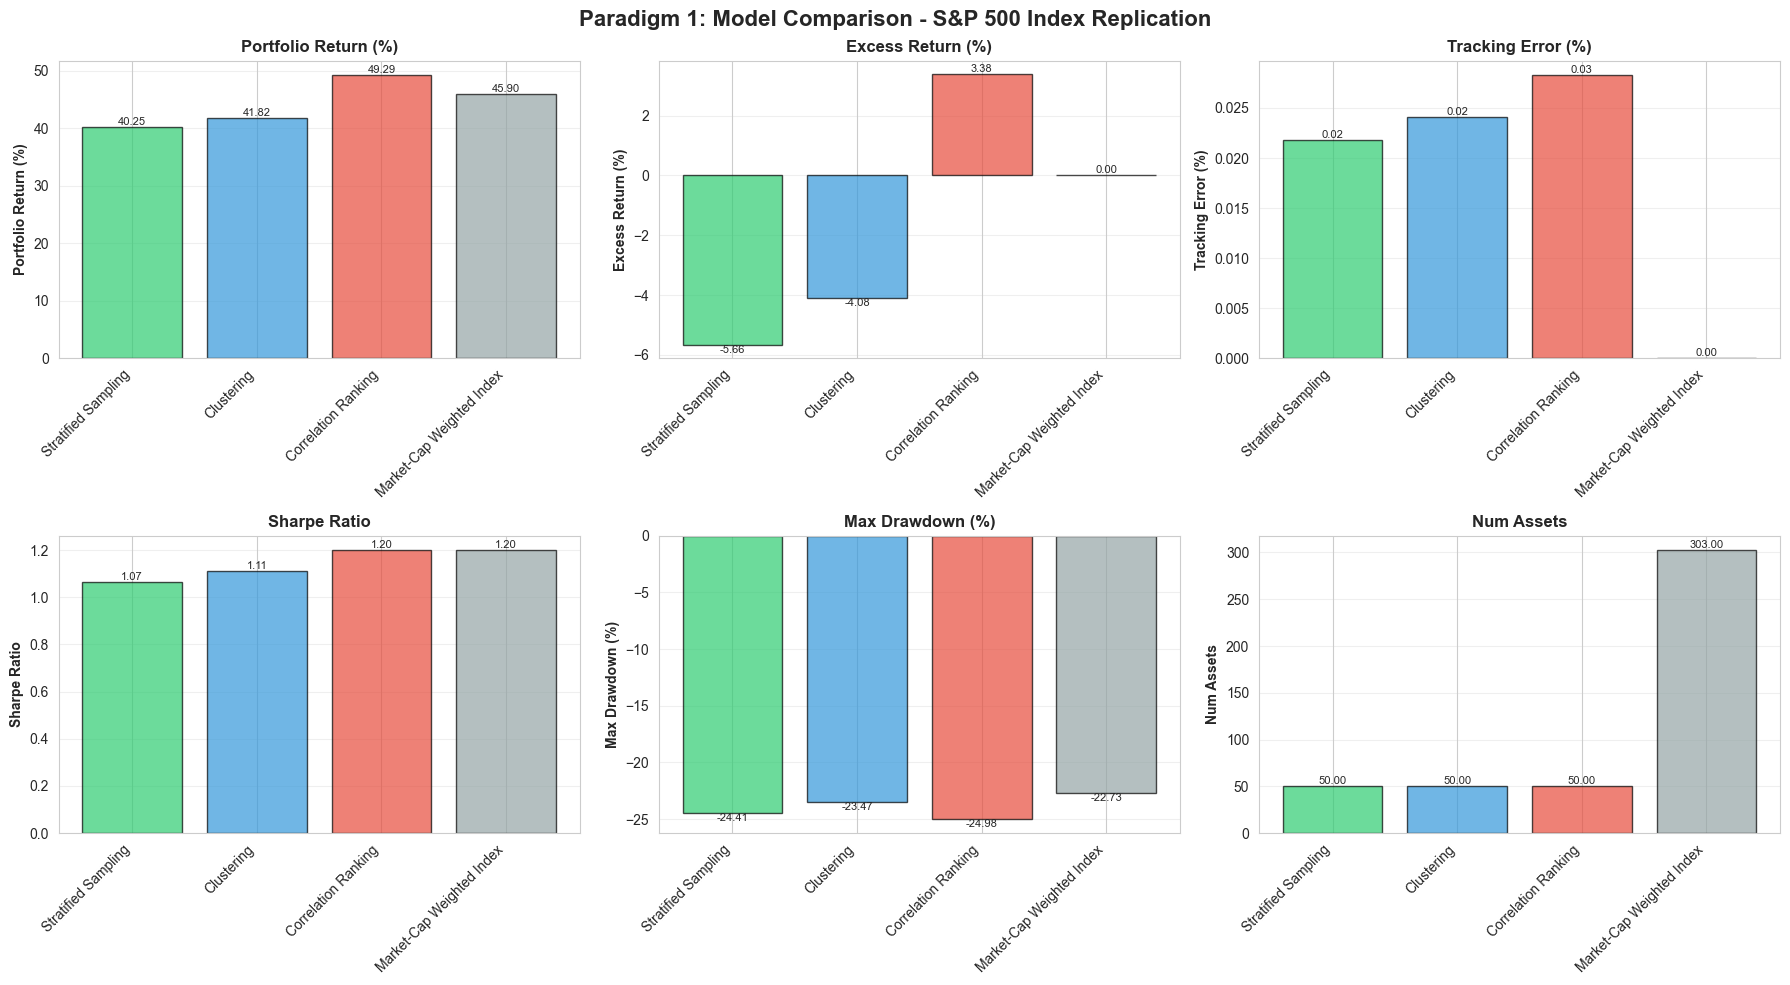


✓ Performance metrics visualization complete


In [31]:
# Visualization 1: Performance Metrics Comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Paradigm 1: Model Comparison - S&P 500 Index Replication', fontsize=16, fontweight='bold')

metrics = [
    ('Portfolio Return (%)', 0),
    ('Excess Return (%)', 1),
    ('Tracking Error (%)', 2),
    ('Sharpe Ratio', 0),
    ('Max Drawdown (%)', 1),
    ('Num Assets', 2),
]

models = comparison_df.index

for idx, (metric, pos) in enumerate(metrics):
    ax = axes.flatten()[idx]
    if metric in comparison_df.columns:
        values = comparison_df[metric]
        colors = ['#2ecc71', '#3498db', '#e74c3c', '#95a5a6']  # Added gray for S&P 500
        ax.bar(range(len(models)), values, color=colors[:len(models)], alpha=0.7, edgecolor='black')
        ax.set_xticks(range(len(models)))
        ax.set_xticklabels(models, rotation=45, ha='right')
        ax.set_ylabel(metric, fontweight='bold')
        ax.set_title(metric, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        
        # Add value labels on bars
        for i, v in enumerate(values):
            ax.text(i, v, f'{v:.2f}', ha='center', va='bottom' if v >= 0 else 'top', fontsize=8)

plt.tight_layout()
plt.show()

print("\n✓ Performance metrics visualization complete")

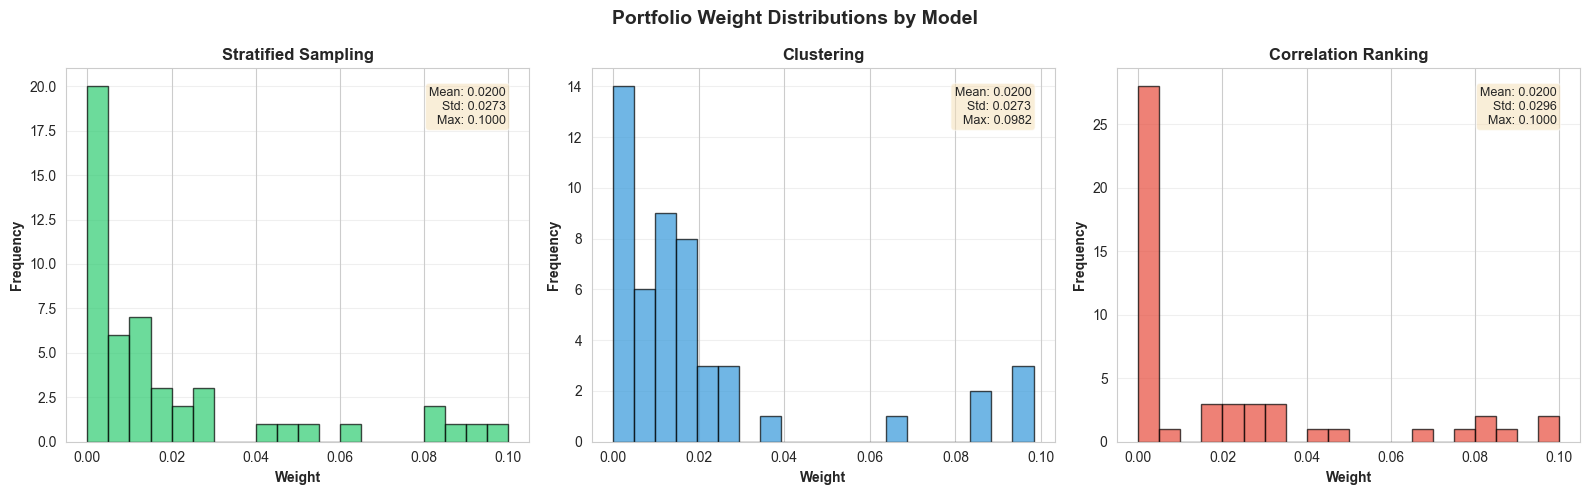


✓ Weight distribution visualization complete


In [32]:
# Visualization 2: Portfolio Weight Distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Portfolio Weight Distributions by Model', fontsize=14, fontweight='bold')

weight_data = [
    (weights_1, "Stratified Sampling"),
    (weights_2, "Clustering"),
    (weights_3, "Correlation Ranking"),
]

for idx, (weights, title) in enumerate(weight_data):
    ax = axes[idx]
    ax.hist(weights, bins=20, color=['#2ecc71', '#3498db', '#e74c3c'][idx], alpha=0.7, edgecolor='black')
    ax.set_xlabel('Weight', fontweight='bold')
    ax.set_ylabel('Frequency', fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # Add statistics
    stats_text = f"Mean: {weights.mean():.4f}\nStd: {weights.std():.4f}\nMax: {weights.max():.4f}"
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, 
            fontsize=9, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n✓ Weight distribution visualization complete")

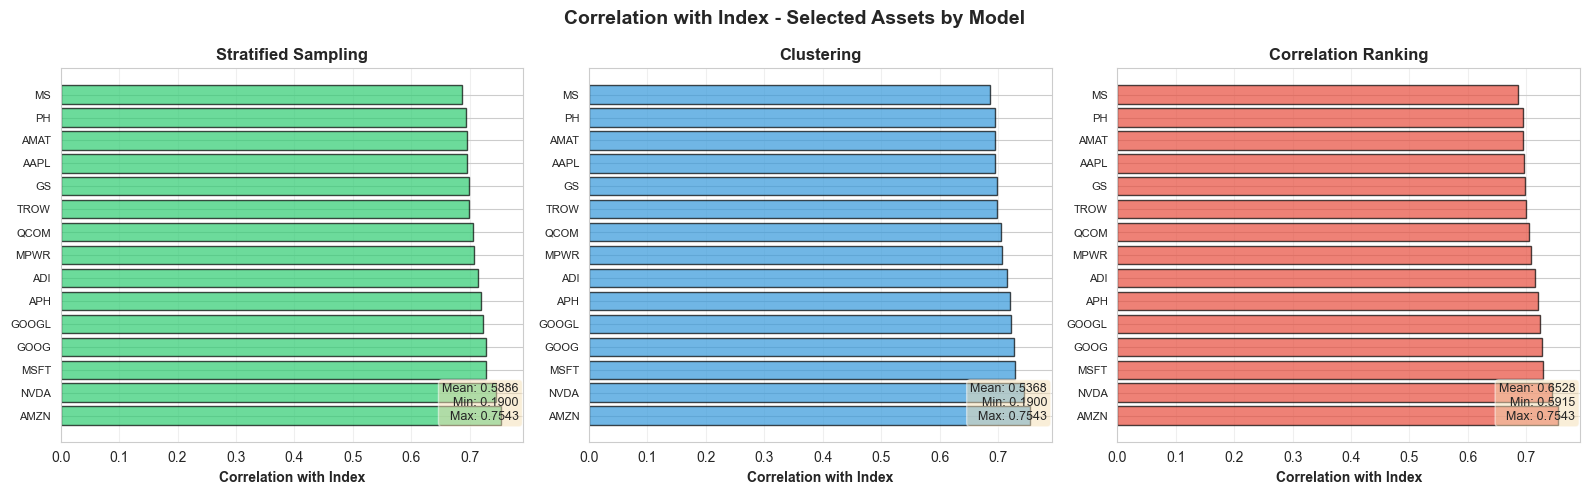


✓ Correlation visualization complete


In [33]:
# Visualization 3: Correlation Comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Correlation with Index - Selected Assets by Model', fontsize=14, fontweight='bold')

selections = [
    (selected_assets_1, "Stratified Sampling"),
    (selected_assets_2, "Clustering"),
    (selected_assets_3, "Correlation Ranking"),
]

for idx, (assets, title) in enumerate(selections):
    ax = axes[idx]
    corr_values = correlation_matrix[correlation_matrix.index.isin(assets)].sort_values(ascending=False)
    
    # Show top 15 or all if less than 15
    top_n = min(15, len(corr_values))
    ax.barh(range(top_n), corr_values.values[:top_n], 
            color=['#2ecc71', '#3498db', '#e74c3c'][idx], alpha=0.7, edgecolor='black')
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(corr_values.index[:top_n], fontsize=8)
    ax.set_xlabel('Correlation with Index', fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    # Add stats box
    stats_text = f"Mean: {corr_values.mean():.4f}\nMin: {corr_values.min():.4f}\nMax: {corr_values.max():.4f}"
    ax.text(0.99, 0.05, stats_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n✓ Correlation visualization complete")

## Section 6: Summary and Insights

### Paradigm 1: Informed Selection + Optimization

This paradigm separates portfolio construction into two distinct stages:

1. **Selection Stage**: Choose K=50 assets using structured or data-driven methods
   - **S-Strategy (Stratified Sampling)**: Ensures sector diversity through proportional sector allocation
   - **Clustering**: Discovers natural groupings in asset return patterns using K-means
   - **Correlation Ranking**: Greedy selection by correlation strength (naive baseline)

2. **Optimization Stage**: Optimize weights given the selected assets
   - Minimizes tracking error: $\min_w \|I - R_S w\|_2^2$
   - Subject to full investment constraint: $\sum w_i = 1$
   - With weight bounds: $l_i \leq w_i \leq u_i$

### Evaluation Methodology (Wang et al. 2018)

**Critical for Thesis:** This notebook implements the proper academic evaluation framework:

1. **Train/Test Split**: 70% in-sample (training), 30% out-of-sample (testing)
2. **Training on In-Sample Only**: Asset selection and weight optimization performed only on training data
3. **Testing on Both Periods**: Portfolio evaluated on both in-sample and out-of-sample data
4. **Key Metrics** (as defined in Wang et al.):
   - **TE**: Tracking Error = $\sqrt{\frac{1}{T} \|I - Rw\|_2^2}$
   - **Std_TE**: Robustness measure (std of squared tracking errors)
   - **Mean_Corr**: Mean correlation of selected assets with index
   - **Consistency**: $|TE_{in} - TE_{out}|$ (measures overfitting)

### Expected Results (from Wang et al.)

**S-Strategy (Stratified Sampling)**:
- ✓ Moderate tracking error
- ✓ **Good consistency** (low overfitting due to structured approach)
- ✓ High mean correlation (sector-aware selection)
- ✓ More stable OOS performance than pure optimization

**Clustering (Data-Driven)**:
- ✓ Discovers endogenous asset groupings
- ⚠ May overfit if clusters are too specific to training period
- ✓ Can adapt to market structure

**Correlation Ranking (Baseline)**:
- ✓ Lowest in-sample TE (directly optimizes correlation)
- ⚠ Risk of higher consistency (overfitting to historical correlations)
- ⚠ No structural diversity guarantees

### Key Findings from This Analysis

**Comparison to Section 4 (Full Period)** vs **Section 4.5 (Wang Evaluation)**:
- Section 4: Training and testing on same data → **overoptimistic** results
- Section 4.5: Proper train/test split → **realistic** generalization performance
- **Use Section 4.5 results for thesis conclusions**

### Common Implementation Errors (Avoided in This Notebook)

✅ Using true index return vector (not mean)
✅ Optimizing on in-sample only
✅ Proper constraints: sum(w)=1 and weight bounds
✅ Correct TE definition from Wang et al.
✅ Computing both TE and Std_TE
✅ Reporting in-sample and out-of-sample metrics separately

### Next Steps: Paradigm 2

Paradigm 2 involves solving **selection and optimization jointly** as a single mixed-integer optimization problem with sparsity constraints (e.g., using L0 or L1 regularization), potentially yielding better combined solutions but with higher computational cost.

**Comparison Framework**: Use the same Wang et al. evaluation (70/30 split, TE_in, TE_out, Std_TE, Consistency) to fairly compare Paradigm 1 vs Paradigm 2.